# Preprocessing of heart cell altas, single donor

In [1]:
library(Signac)
library(Seurat)
library(GenomicRanges)
library(data.table)

library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)

library(GenomeInfoDb)
library(IRanges)
library(rtracklayer)
library(ggplot2)
library(dplyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    uns

## Preprocessing with Signac:
https://stuartlab.org/signac/articles/pbmc_multiomic

In [2]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data_renamed_genes"
heart_cell_atlas = readRDS(file.path(out_dir, paste0(sample_to_use, ".rds")))

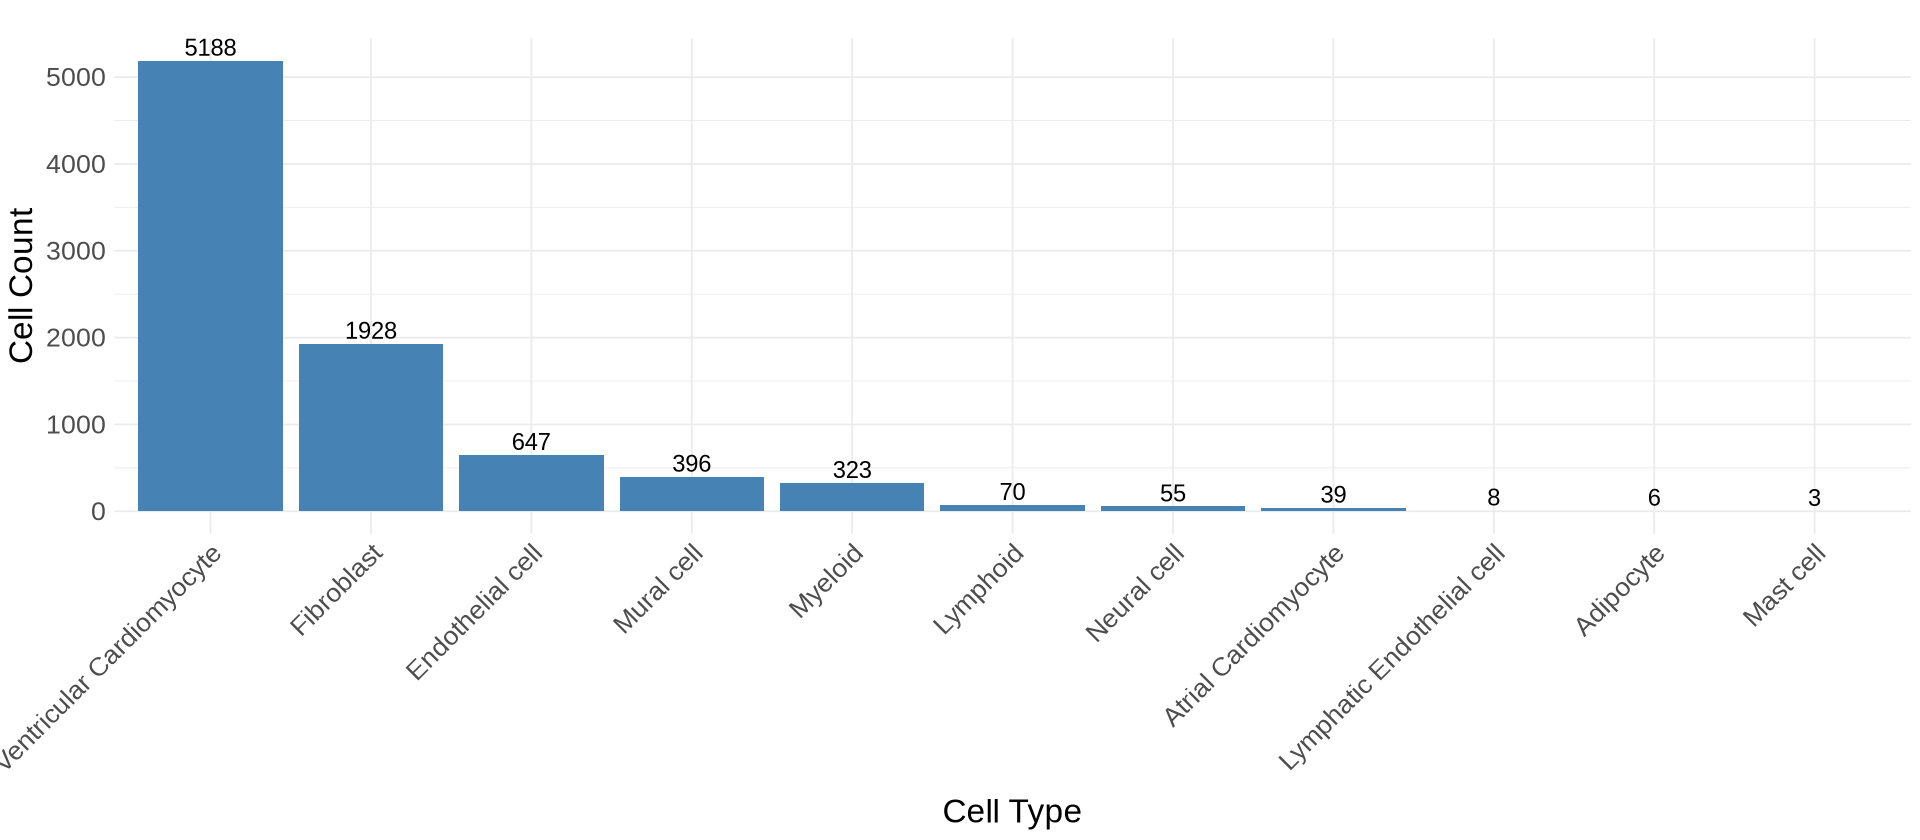

In [14]:
options(repr.plot.width = 16, repr.plot.height = 7)

cell_type_counts <- heart_cell_atlas@meta.data %>%
    group_by(cell_type) %>%
    summarise(count = n(), .groups = "drop") %>%
    arrange(desc(count)) %>%
    mutate(cell_type = factor(cell_type, levels = cell_type))

ggplot(cell_type_counts, aes(x = cell_type, y = count)) +
    geom_bar(stat = "identity", fill = "steelblue") +
    geom_text(aes(label = count), vjust = -0.3, size = 5) +
    theme_minimal() +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1, size = 16),
        axis.text.y = element_text(size = 16),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20)
    ) +
    labs(title = "", x = "Cell Type", y = "Cell Count")

# QUALITY CONTROL PER CELL

-  DNA accessability -> remove outliers
- unusual low count for RNA/ATAC assay
- unusual high count for RNA/ATAC assay

### Transcription Start Site Enrichment: 0:positive values

- relative abundance of signal close to TSS compared to background = genomic region
- inside into: transcription activity and regulatory elements near the TSS
- high TSS enrichment -> active transcription, potential regulatory element (if TSS<1, remove cell)

### Nucleosome Signal
- density or occupancy of nucleosomes along the genome: info about accessibility
- high signal indicates higher density of nucleosomes (less accessible)
- only keep cells with low score (more accessible)

## RNA Assay first

In [4]:
str(heart_cell_atlas, max.level = 3)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 2
  .. ..$ RNA  :Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..$ Peaks:Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ meta.data   :'data.frame':	8663 obs. of  65 variables:
  .. ..$ orig.ident                 : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA                 : num [1:8663] 43638 43412 43046 42855 41260 ...
  .. ..$ nFeature_RNA               : int [1:8663] 7264 7321 7281 7213 7129 7122 7247 6740 7865 7375 ...
  .. ..$ sangerID                   : chr [1:8663] "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" ...
  .. ..$ combinedID                 : chr [1:8663] "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST11445771" ...
  .. ..$ donor                      : chr [1:8663] "A61

In [5]:
head(heart_cell_atlas@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,sangerID,combinedID,donor,donor_type,region,region_finest,age,⋯,peak_facility,peak_cell_or_nuclei,peak_modality,peak_kit_10x,peak_flushed,peak_batch_key,peak_cell_type,peak_cell_state,nCount_Peaks,nFeature_Peaks
,<fct>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>
ACCACATAGGGCTAAA-1,SeuratProject,43638,7264,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM1,19375,11341
ACATTAGTCCTAGTAA-1,SeuratProject,43412,7321,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM4,42901,23864
TCGGTTCTCGGGACCT-1,SeuratProject,43046,7281,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM1,42000,23196
AGACTATGTAACCAGC-1,SeuratProject,42855,7213,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM1,8144,4948
ATTATCCTCGCACACA-1,SeuratProject,41260,7129,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM1,32422,17983
CGCACACAGGTTACAC-1,SeuratProject,40003,7122,HCAHeartST11350194,HCAHeartST11350194_HCAHeartST11445771,A61,DCD,AVN,AVN SEPT LAT,70-75,⋯,Sanger,Nuclei,Multiome-RNA,Multiome-v1,yes,A61_Nuclei_Multiome-v1,Ventricular Cardiomyocyte,vCM1,54036,30094


In [6]:
head(heart_cell_atlas@meta.data[c("pct_counts_mt", "total_counts_mt", "total_counts")])

,pct_counts_mt,total_counts_mt,total_counts
,<dbl>,<dbl>,<dbl>
ACCACATAGGGCTAAA-1,0.03381272,15,44362
ACATTAGTCCTAGTAA-1,3.92981360,1729,43997
TCGGTTCTCGGGACCT-1,0.04115697,18,43735
AGACTATGTAACCAGC-1,0.02749771,12,43640
ATTATCCTCGCACACA-1,0.03092808,13,42033
CGCACACAGGTTACAC-1,0.09346024,38,40659


In [7]:
summary(heart_cell_atlas@meta.data[c("pct_counts_mt", "total_counts_mt", "total_counts")])

 pct_counts_mt     total_counts_mt    total_counts  
 Min.   :0.00000   Min.   :   0.00   Min.   :  500  
 1st Qu.:0.05015   1st Qu.:   3.00   1st Qu.: 1387  
 Median :0.15848   Median :   6.00   Median : 3704  
 Mean   :0.55546   Mean   :  16.99   Mean   : 5191  
 3rd Qu.:0.62252   3rd Qu.:  15.00   3rd Qu.: 7233  
 Max.   :4.99076   Max.   :1729.00   Max.   :44362  

In [8]:
heart_cell_atlas@meta.data["percent.mt"] <- heart_cell_atlas@meta.data["pct_counts_mt"]

In [11]:
healthy_breast <- readRDS("/nfs/data3/mopitas/mapra/multiome_data/diverse_ancestry_2024/KTB_pool-4-Ashkenazi_jew/rds_files/healthy_breast_peaks_called.rds")

In [14]:
str(healthy_breast, max.level = 3)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 3
  .. ..$ RNA  :Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..$ ATAC :Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  .. ..$ peaks:Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ meta.data   :'data.frame':	6913 obs. of  12 variables:
  .. ..$ orig.ident           : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA           : num [1:6913] 10094 354 777 1119 369 ...
  .. ..$ nFeature_RNA         : int [1:6913] 4337 321 621 854 315 3702 2741 214 2218 571 ...
  .. ..$ nCount_ATAC          : num [1:6913] 26820 1405 10806 10466 2414 ...
  .. ..$ nFeature_ATAC        : int [1:6913] 11808 751 5225 5073 1259 6024 5450 1670 3719 361 ...
  .. ..$ percent.mt           : num [1:6913] 0.0297 0.2825 1.4157 0.0894 0 ...
  .. ..$ nucleosome_signal    : num [1:6913] 0.765 0.677 1.013 0.787 0.486 ...
  .. ..$ nucleosome_percentil

In [9]:
colnames(heart_cell_atlas@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sangerID"                   
 [5] "combinedID"                  "donor"                      
 [7] "donor_type"                  "region"                     
 [9] "region_finest"               "age"                        
[11] "gender"                      "facility"                   
[13] "cell_or_nuclei"              "modality"                   
[15] "kit_10x"                     "flushed"                    
[17] "n_genes"                     "n_genes_by_counts"          
[19] "total_counts"                "total_counts_mt"            
[21] "pct_counts_mt"               "total_counts_ribo"          
[23] "pct_counts_ribo"             "scrublet_score"             
[25] "scrublet_leiden"             "cluster_scrublet_score"     
[27] "doublet_pval"                "doublet_bh_pval"            
[29] "batch_key"                   "leiden_scVI"                
[31] "cell_type"                   "cell_state_HCAv1"           
[33] "cell_state_scNym"            "cell_state_scNym_confidence"
[35] "cell_state"                  "latent_RT_efficiency"       
[37] "latent_cell_probability"     "latent_scale"               
[39] "n_counts"                    "_scvi_batch"                
[41] "_scvi_labels"                "clus20"                     
[43] "doublet_cls"                 "original_or_new"            
[45] "batch"                       "scANVI_predictions"         
[47] "leiden_scArches"             "peak_sangerID"              
[49] "peak_combinedID"             "peak_donor"                 
[51] "peak_donor_type"             "peak_region"                
[53] "peak_region_finest"          "peak_age"                   
[55] "peak_gender"                 "peak_facility"              
[57] "peak_cell_or_nuclei"         "peak_modality"              
[59] "peak_kit_10x"                "peak_flushed"               
[61] "peak_batch_key"              "peak_cell_type"             
[63] "peak_cell_state"             "nCount_Peaks"               
[65] "nFeature_Peaks"              "percent.mt"

In [10]:
# change plot size, make wider
options(repr.plot.width=15, repr.plot.height=10)

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


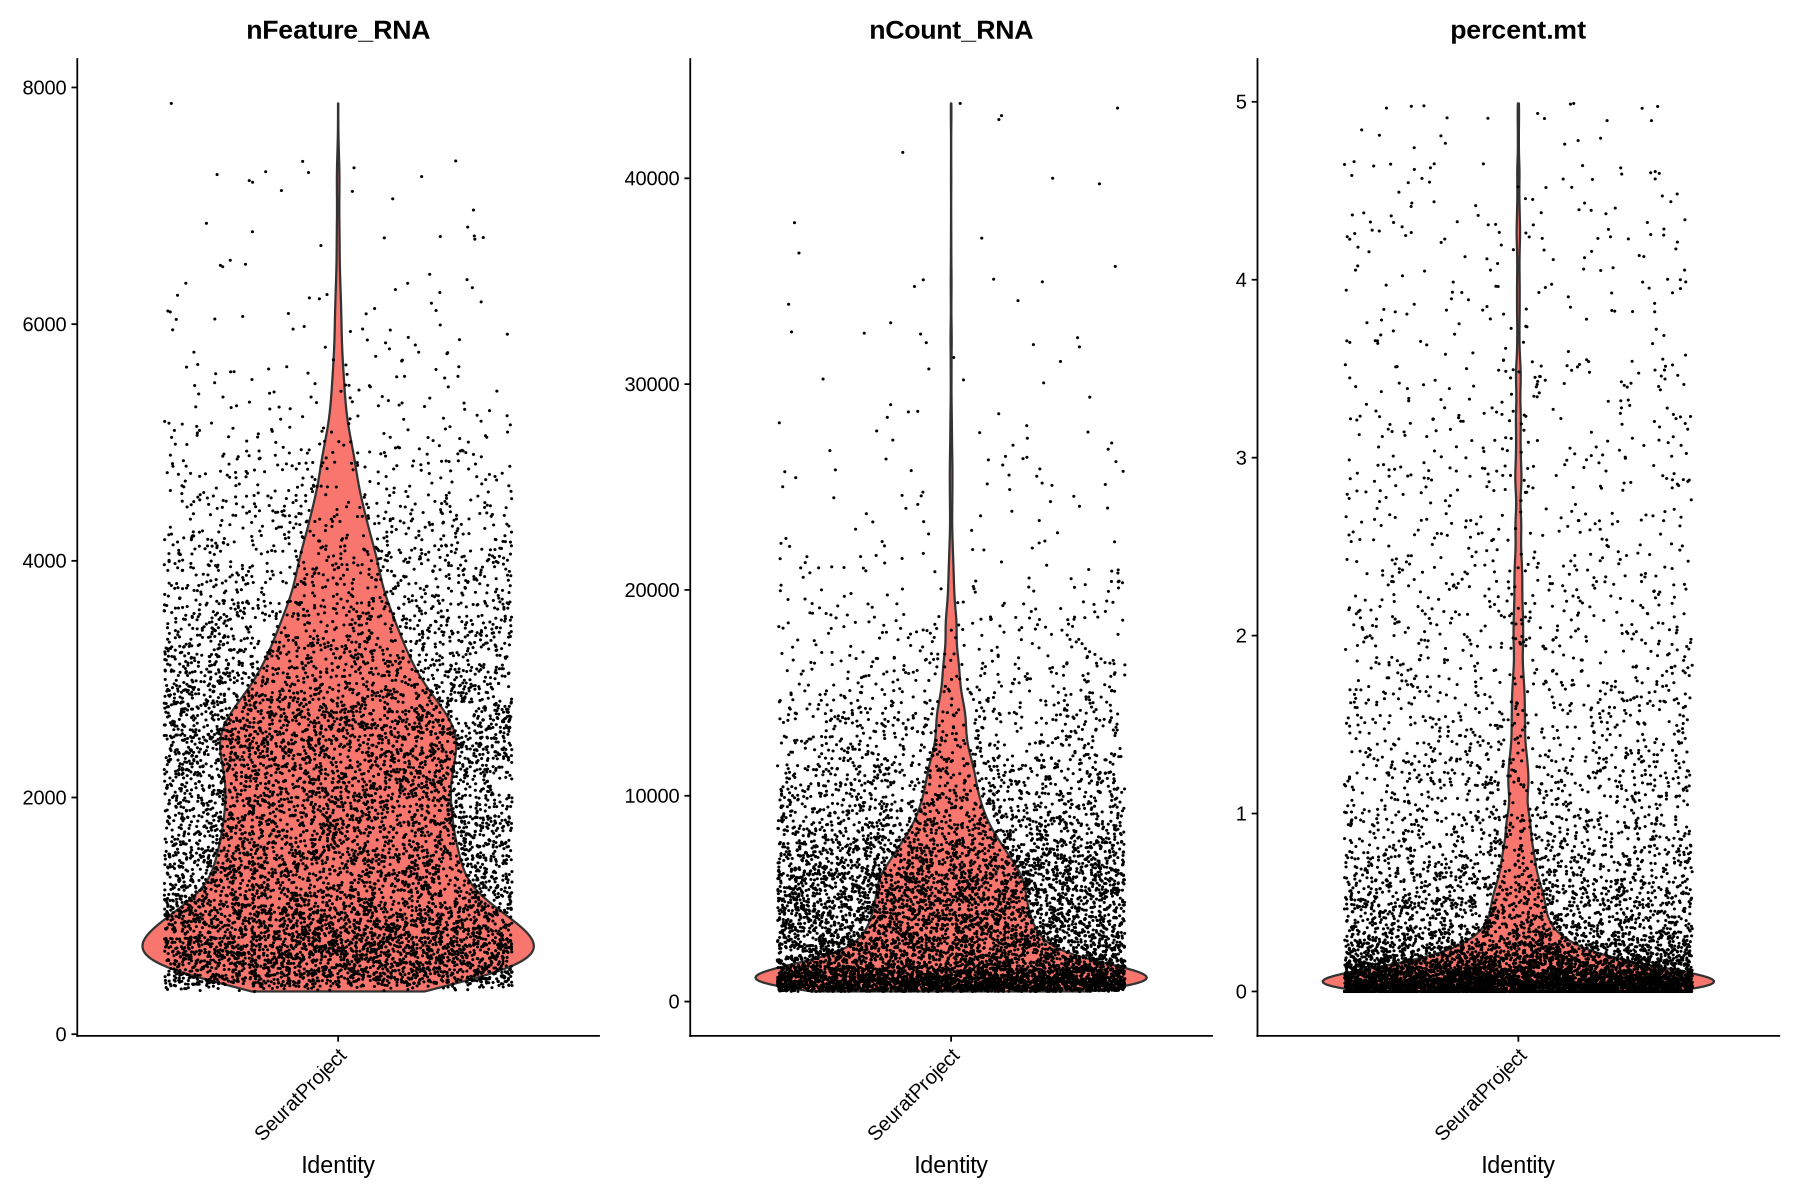

In [11]:
VlnPlot(heart_cell_atlas, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)

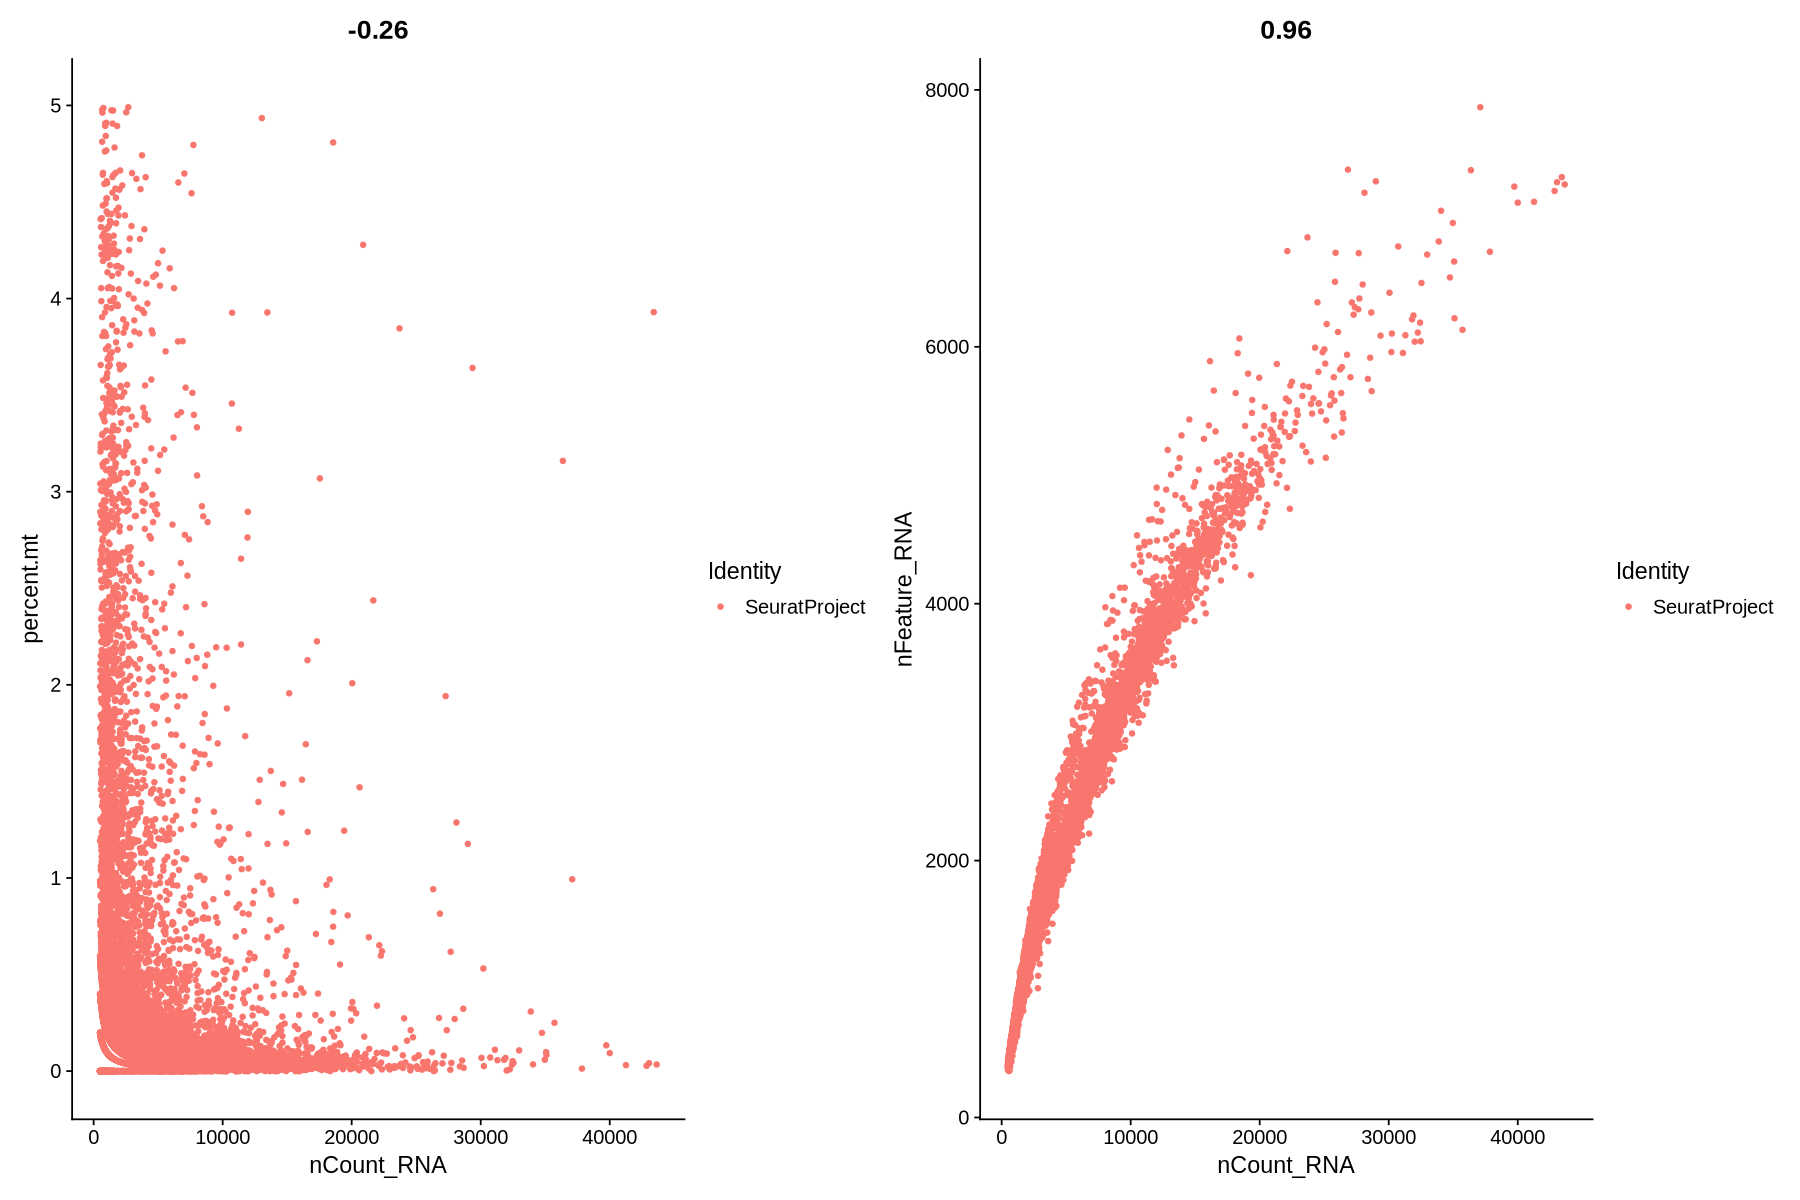

In [12]:
plot1 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

In [13]:
countLOW=quantile(heart_cell_atlas$nCount_RNA, prob=c(0.01))  
countHIGH=quantile(heart_cell_atlas$nCount_RNA, prob=0.99) 
featureLOW=quantile(heart_cell_atlas$nFeature_RNA, prob=0.01)
featureHIGH=quantile(heart_cell_atlas$nFeature_RNA, prob=0.99)

In [14]:
countLOW
countHIGH
featureLOW
featureHIGH

1% 
530.62

99% 
22821.08

1% 
422

99% 
5548.8

In [15]:
# 1. Filter Cells by #features and %mt

# filter cells that have unique feature counts over 7000 (doublets) or less than 200 (low quality)
# filter cells that have >5% mitochondrial counts (low quality, dying)

heart_cell_atlas <- subset(heart_cell_atlas, subset = nFeature_RNA > 300 & nFeature_RNA < 7000 & percent.mt < 5)

In [16]:
heart_cell_atlas

An object of class Seurat 
462552 features across 8650 samples within 2 assays 
Active assay: RNA (32724 features, 0 variable features)
 1 layer present: counts
 1 other assay present: Peaks

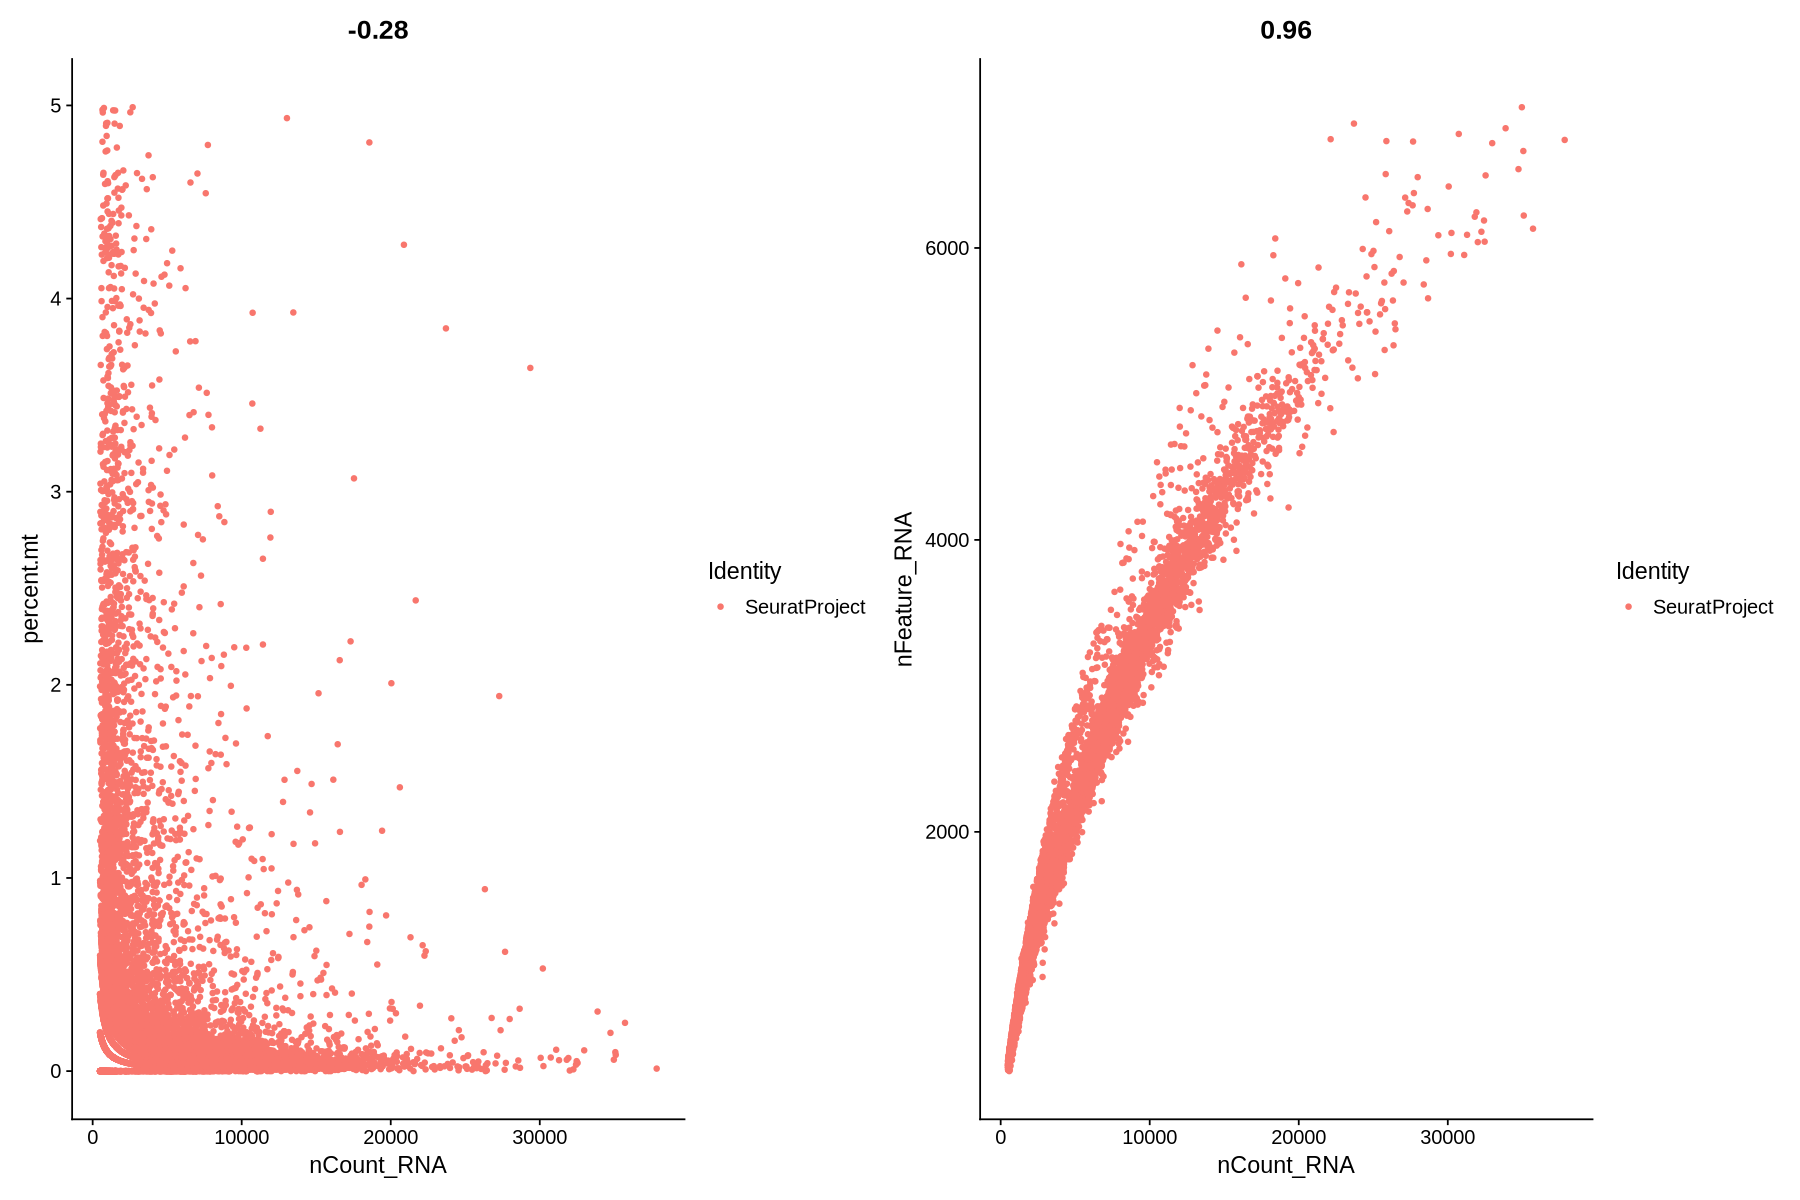

In [17]:
plot1 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(heart_cell_atlas, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2

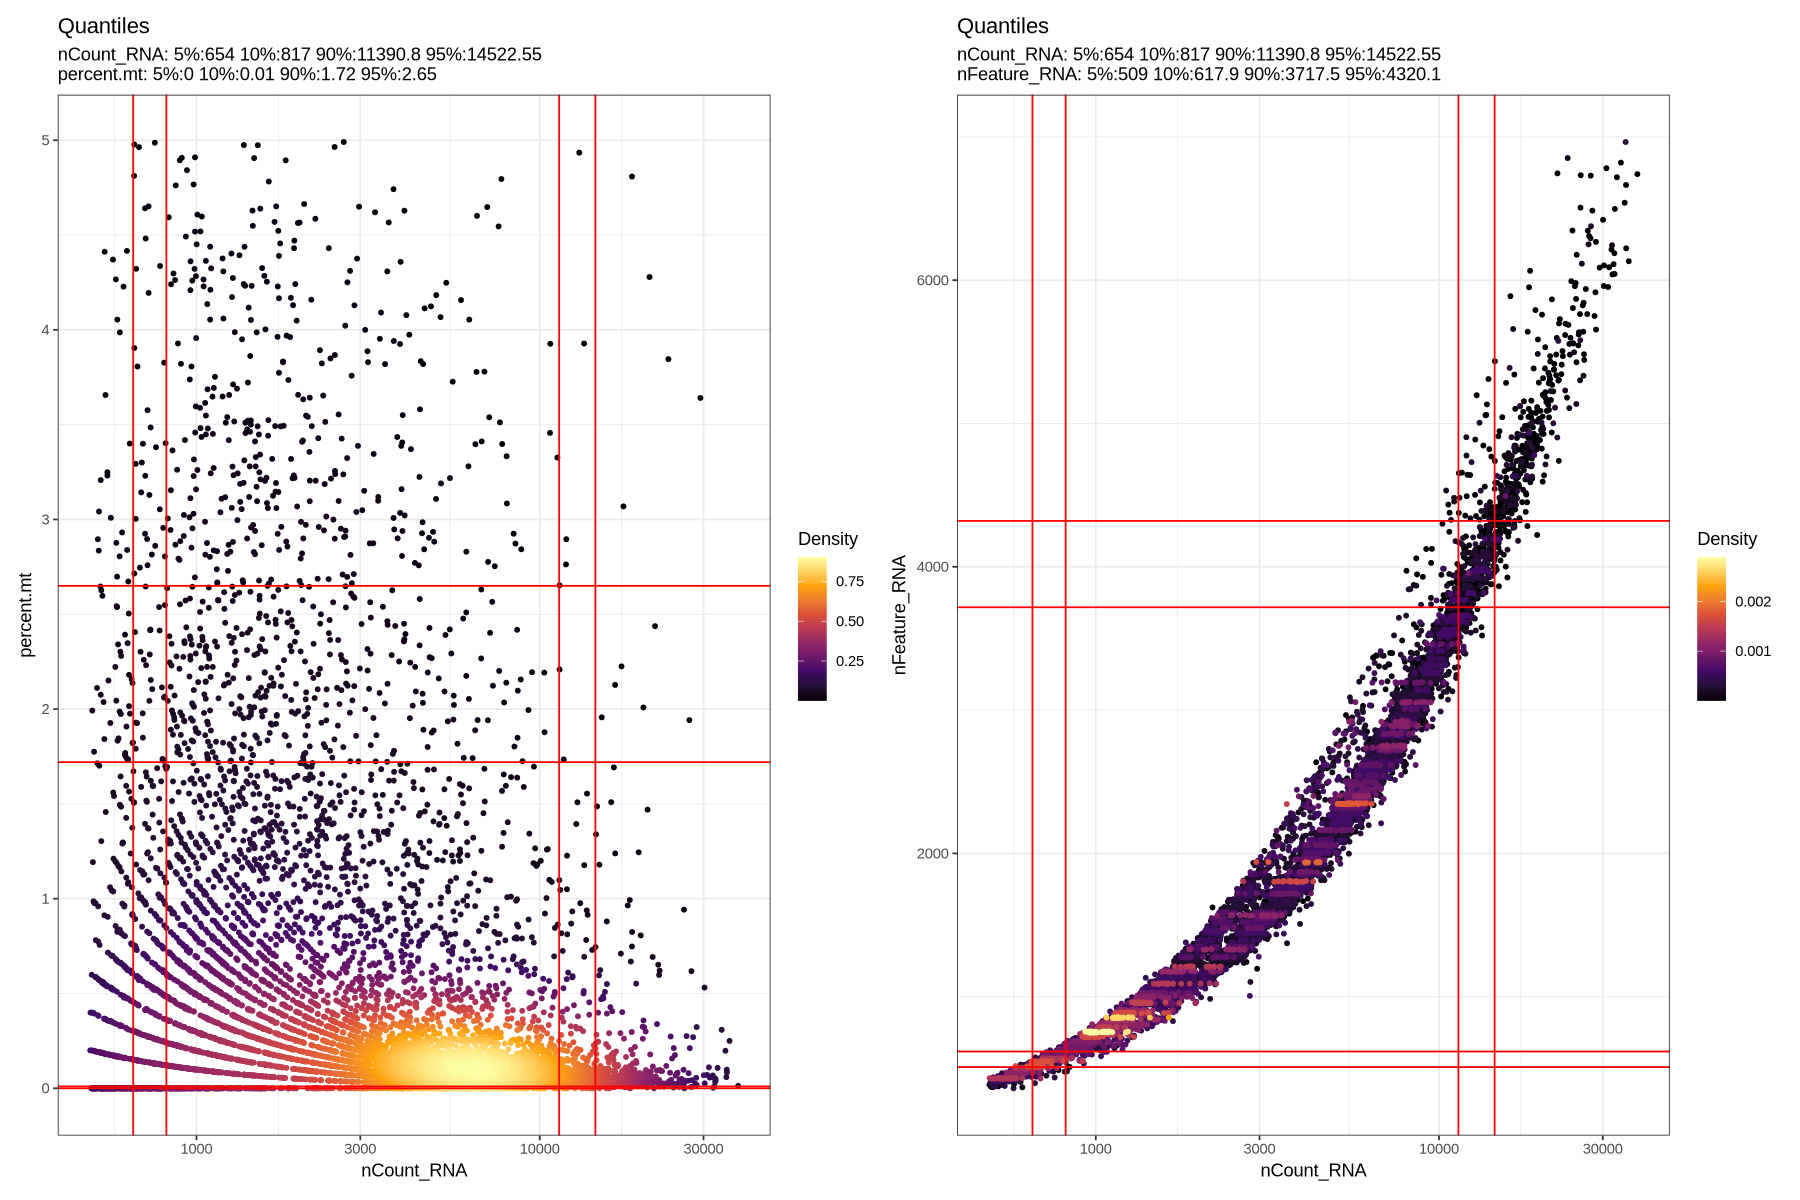

In [18]:
plot1 <-DensityScatter(heart_cell_atlas, x = 'nCount_RNA', y = 'percent.mt', log_x = TRUE, quantiles = TRUE)
plot2 <-DensityScatter(heart_cell_atlas, x = 'nCount_RNA', y = 'nFeature_RNA', log_x = TRUE, quantiles = TRUE)
plot1 + plot2

## ATAC Assay next

In [19]:
DefaultAssay(heart_cell_atlas) <- "Peaks"

heart_cell_atlas <- NucleosomeSignal(heart_cell_atlas)
heart_cell_atlas <- TSSEnrichment(heart_cell_atlas)# Transcription Start Site Enrichment


Extracting TSS positions

Extracting fragments at TSSs


Computing TSS enrichment score



In [20]:
colnames(heart_cell_atlas@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "sangerID"                   
 [5] "combinedID"                  "donor"                      
 [7] "donor_type"                  "region"                     
 [9] "region_finest"               "age"                        
[11] "gender"                      "facility"                   
[13] "cell_or_nuclei"              "modality"                   
[15] "kit_10x"                     "flushed"                    
[17] "n_genes"                     "n_genes_by_counts"          
[19] "total_counts"                "total_counts_mt"            
[21] "pct_counts_mt"               "total_counts_ribo"          
[23] "pct_counts_ribo"             "scrublet_score"             
[25] "scrublet_leiden"             "cluster_scrublet_score"     
[27] "doublet_pval"                "doublet_bh_pval"            
[29] "batch_key"                   "leiden_scVI"                
[31] "cell_type"                   "cell_state_HCAv1"           
[33] "cell_state_scNym"            "cell_state_scNym_confidence"
[35] "cell_state"                  "latent_RT_efficiency"       
[37] "latent_cell_probability"     "latent_scale"               
[39] "n_counts"                    "_scvi_batch"                
[41] "_scvi_labels"                "clus20"                     
[43] "doublet_cls"                 "original_or_new"            
[45] "batch"                       "scANVI_predictions"         
[47] "leiden_scArches"             "peak_sangerID"              
[49] "peak_combinedID"             "peak_donor"                 
[51] "peak_donor_type"             "peak_region"                
[53] "peak_region_finest"          "peak_age"                   
[55] "peak_gender"                 "peak_facility"              
[57] "peak_cell_or_nuclei"         "peak_modality"              
[59] "peak_kit_10x"                "peak_flushed"               
[61] "peak_batch_key"              "peak_cell_type"             
[63] "peak_cell_state"             "nCount_Peaks"               
[65] "nFeature_Peaks"              "percent.mt"                 
[67] "nucleosome_signal"           "nucleosome_percentile"      
[69] "TSS.enrichment"              "TSS.percentile"

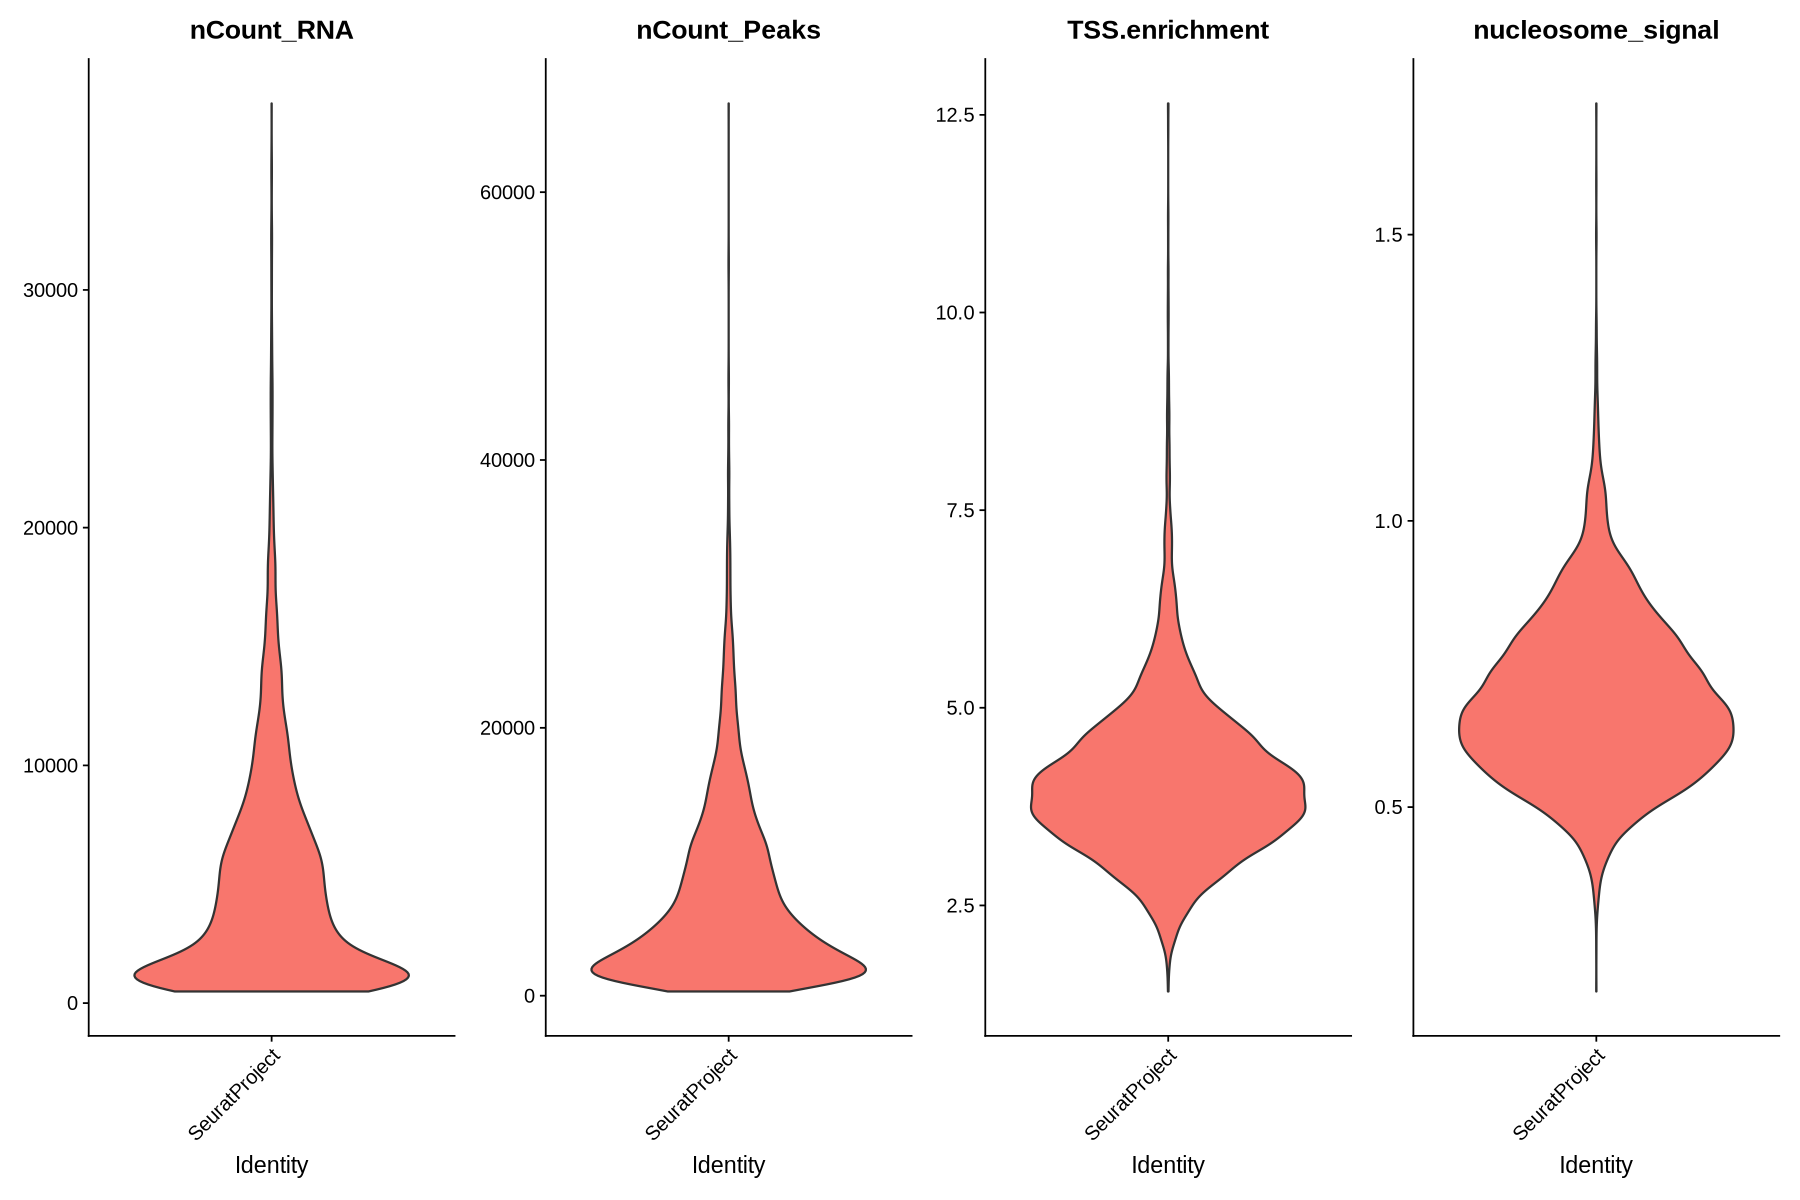

In [21]:

VlnPlot(
  object = heart_cell_atlas,
  features = c("nCount_RNA", "nCount_Peaks", "TSS.enrichment", "nucleosome_signal"),
  ncol = 4,
  pt.size = 0
)

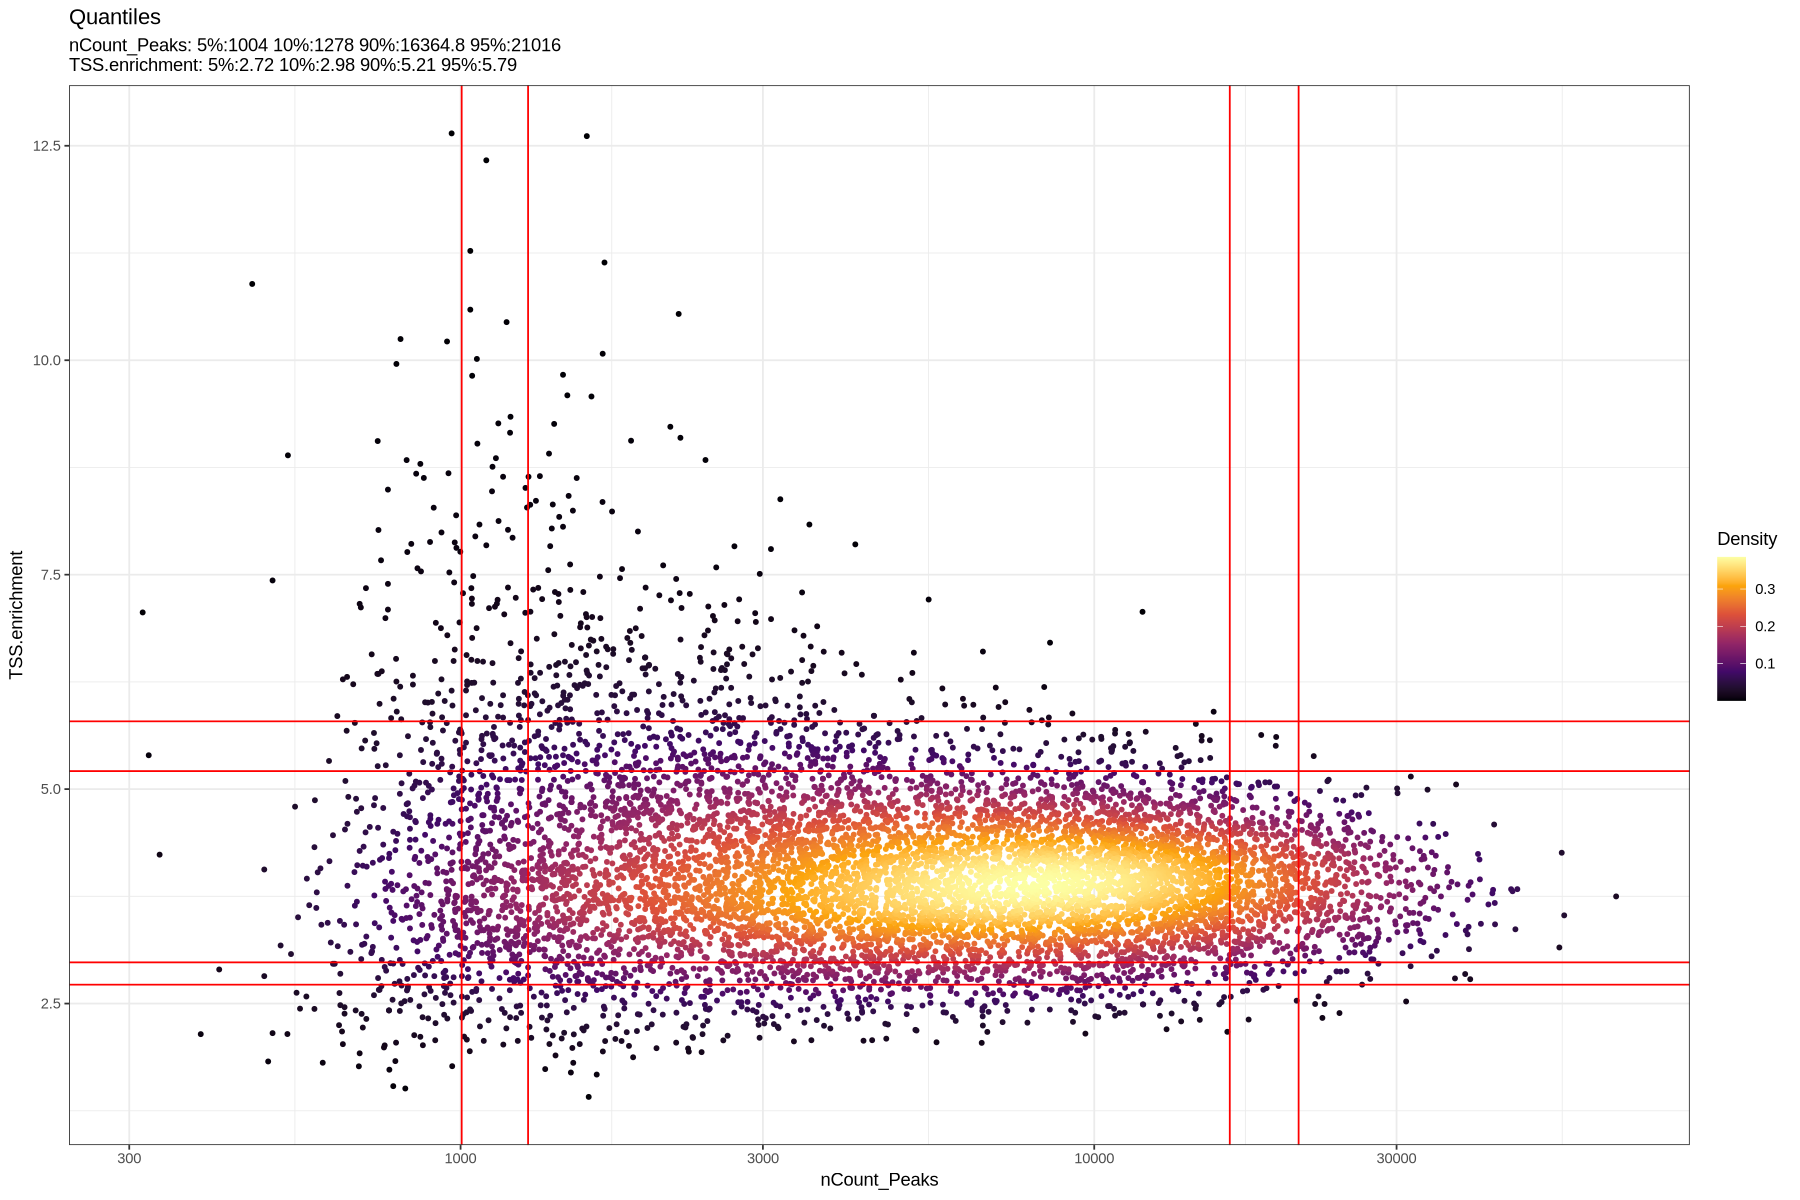

In [22]:
DensityScatter(heart_cell_atlas, x = 'nCount_Peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

In [23]:
# Because very low nCount_RNA usually means the barcode captured too little RNA to represent a real, informative cell.
# nCount_RNA is the total UMI count per cell. When it is very low, several problems become more likely:
# the droplet may be empty or nearly empty
# it may contain ambient RNA rather than a true cell
# the cell may be damaged or partially lysed
# gene expression becomes very sparse and noisy, so clustering and marker detection get worse
# So a cutoff like nCount_RNA > 500 is just a practical way to remove the weakest barcodes.


In [23]:
nCount_RNALOW=quantile(heart_cell_atlas$nCount_RNA, prob=c(0.01))  
nCount_RNAHIGH=quantile(heart_cell_atlas$nCount_RNA, prob=0.99) 
nCount_ATACLOW=quantile(heart_cell_atlas$nCount_Peaks, prob=c(0.01))  
nCount_ATACHIGH=quantile(heart_cell_atlas$nCount_Peaks, prob=0.99)

In [24]:
nCount_RNALOW
nCount_RNAHIGH
nCount_ATACLOW
nCount_ATACHIGH

1% 
530.49

99% 
21859.68

1% 
710

99% 
31199.64

In [25]:
heart_cell_atlas <- subset(
  x = heart_cell_atlas,
  subset = nCount_Peaks < 30000 &
    nCount_RNA < 20000 &
    nCount_Peaks > 700 &
    nCount_RNA > 500 &
    nucleosome_signal < 2 &
    TSS.enrichment > 1
)
heart_cell_atlas

An object of class Seurat 
462552 features across 8358 samples within 2 assays 
Active assay: Peaks (429828 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: RNA

## CALL PEAKS using CallPeaks() with MACS2

- call peaks on all cells together
- opt: identify peaks for each group of cells separately: group.by parameter -> identify peaks specific to rare cell populations

In [26]:
path_to_macs2 = '/nfs/home/students/m.back/.conda/envs/mzb_macs2/bin/macs2'

In [27]:
path_to_macs2

[1] "/nfs/home/students/m.back/.conda/envs/mzb_macs2/bin/macs2"

In [28]:

path_to_macs2 = '/nfs/home/students/m.back/.conda/envs/mzb_macs2_py310/bin/macs2'

DefaultAssay(heart_cell_atlas) <- "Peaks"
peaks_macs2 <- CallPeaks(heart_cell_atlas, 
                    macs2.path=path_to_macs2, 
                    outdir = out_dir,
                    # effective.genome.size = 2.7e9, 
                    cleanup = FALSE
                    )
peaks_macs2

GRanges object with 126975 ranges and 6 metadata columns:
             seqnames            ranges strand |                   name
                <Rle>         <IRanges>  <Rle> |            <character>
       [1] GL000194.1       21353-21611      * |   SeuratProject_peak_1
       [2] GL000194.1       24168-25355      * |   SeuratProject_peak_2
       [3] GL000194.1       55936-56674      * |   SeuratProject_peak_3
       [4] GL000194.1       58297-58724      * |   SeuratProject_peak_4
       [5] GL000194.1       59794-60263      * |   SeuratProject_peak_5
       ...        ...               ...    ... .                    ...
  [126971]       chrY 56857848-56858244      * | SeuratProject_peak_1..
  [126972]       chrY 56858619-56859060      * | SeuratProject_peak_1..
  [126973]       chrY 56861338-56861684      * | SeuratProject_peak_1..
  [126974]       chrY 56869767-56870173      * | SeuratProject_peak_1..
  [126975]       chrY 56870799-56871078      * | SeuratProject_peak_1..
      

## remove peaks on nonstandard chromosomes and in genomic blacklist regions

genomic blacklist regions:
- these regions are prone to produce misleading or false-positive signals
- due to factors like repetitive sequences, mapping errors, or experimental artifacts.

In [29]:
peaks_macs2 <- keepStandardChromosomes(peaks_macs2, pruning.mode = "coarse")
peaks_macs2 <- subsetByOverlaps(x = peaks_macs2, ranges = blacklist_hg38_unified, invert = TRUE) # exclude gbrs (as invert is set to true)  

In [30]:
# quantify counts in each peak
macs2_counts <- FeatureMatrix(
  fragments = Fragments(heart_cell_atlas),
  features = peaks_macs2,
  cells = colnames(heart_cell_atlas)
)

Extracting reads overlapping genomic regions



In [31]:
annotation <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [32]:
seqlevels(annotation) <- paste0("chr", seqlevels(annotation))
annotation

GRanges object with 3021151 ranges and 5 metadata columns:
                  seqnames        ranges strand |           tx_id   gene_name
                     <Rle>     <IRanges>  <Rle> |     <character> <character>
  ENSE00001489430     chrX 276322-276394      + | ENST00000399012      PLCXD1
  ENSE00001536003     chrX 276324-276394      + | ENST00000484611      PLCXD1
  ENSE00002160563     chrX 276353-276394      + | ENST00000430923      PLCXD1
  ENSE00001750899     chrX 281055-281121      + | ENST00000445062      PLCXD1
  ENSE00001489388     chrX 281192-281684      + | ENST00000381657      PLCXD1
              ...      ...           ...    ... .             ...         ...
  ENST00000361739    chrMT     7586-8269      + | ENST00000361739      MT-CO2
  ENST00000361789    chrMT   14747-15887      + | ENST00000361789      MT-CYB
  ENST00000361851    chrMT     8366-8572      + | ENST00000361851     MT-ATP8
  ENST00000361899    chrMT     8527-9207      + | ENST00000361899     MT-ATP6
  ENS

In [33]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
fragpath <- paste0("/nfs/data3/mopitas/mapra/cell_atlas_data/", sample_to_use, "_atac_fragments.tsv.gz")

stopifnot(file.exists(fragpath))

In [34]:
# create a new assay using the MACS2 peak set and add it to the Seurat object
heart_cell_atlas[["peaks_macs2"]] <- CreateChromatinAssay(
  counts = macs2_counts,
  fragments = fragpath,
  annotation = annotation
)
heart_cell_atlas

Computing hash



An object of class Seurat 
589298 features across 8358 samples within 3 assays 
Active assay: Peaks (429828 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, peaks_macs2

In [35]:
heart_cell_atlas[["peaks_macs2"]]@data[1:20,1:10]

  [[ suppressing 10 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]



20 x 10 sparse Matrix of class "dgCMatrix"
                                      
chr1-180726-181592 . . . . . . . . . .
chr1-191296-191598 . 1 . . . . . . . .
chr1-777673-779298 . . . . . . . . . .
chr1-816970-817414 . . . . . . . . . .
chr1-826849-827669 . . . . . . . . . .
chr1-831309-831553 . . . . . . . . . .
chr1-832099-832600 . . . . . . . . . .
chr1-837599-837798 . . . . . . . . . .
chr1-843950-844232 . . . . . . . . . .
chr1-844553-844950 . . . . . . . . . .
chr1-849979-850595 . . . . . . . . . .
chr1-856155-856369 . . . . . . . . . .
chr1-858626-859058 . . . 1 1 . . . . .
chr1-865187-866425 . . . . . . . . 1 .
chr1-869542-870192 . . . . . . . . . .
chr1-875330-875555 . . . . . . . . . .
chr1-876313-876970 . . . . . . . . . .
chr1-903855-905483 . . . . . . . . . .
chr1-906729-907018 . . . . . . . . . .
chr1-909973-910699 . . . . . . . . . .

In [36]:
saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called.rds"), compress = "xz") 

## Normalization and PCA
### Gene expression (RNA) data processing

- normalize gene expression data: SCTransform

It uses a regularized negative binomial regression model to estimate the mean-variance relationship of each gene, allowing for the transformation of the data to a more approximately normal distribution. This transformation helps to reduce the dependence of variance on the mean, which is often observed in scRNA-seq data

- reduce the dimensionality: PCA

In [37]:
library(glmGamPoi)


Attaching package: 'glmGamPoi'


The following object is masked from 'package:dplyr':

    vars


The following object is masked from 'package:ggplot2':

    vars




In [38]:
DefaultAssay(heart_cell_atlas) <- "RNA"

heart_cell_atlas <- SCTransform(  # this is an alternative to NormalizeData + FindVariableFeatures + ScaleData
  heart_cell_atlas,
  vst.flavor = "v2",
  method = "glmGamPoi", # fast Poisson-Gamma model
  variable.features.n = 3000,
  conserve.memory = TRUE, # useful for large data
  verbose = TRUE)
  
heart_cell_atlas <- RunPCA(heart_cell_atlas, reduction.name = "pca_sct")

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi



Variance stabilizing transformation of count matrix of size 22266 by 8358

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 5000 cells

Found 174 outliers - those will be ignored in fitting/regularization step


Skip calculation of full residual matrix

Will not return corrected UMI because residual type is not set to 'pearson'

Calculating gene attributes

Wall clock passed: Time difference of 16.37852 secs

Setting min_variance based on median UMI:  0.04

Calculating variance for residuals of type pearson for 22266 genes

Determine variable features

Setting min_variance based on median UMI:  0.04

Calculating residuals of type pearson for 3000 genes



  |======================================================================| 100%


Computing corrected UMI count matrix

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT

PC_ 1 
Positive:  FGF12, FHL2, RYR2, SORBS2, DMD, CTNNA3, PDE3A, SLC8A1, PDK4, CACNB2 
	   NEBL, MLIP, TECRL, CACNA1C, TTN, ANKRD1, TTN-AS1, AKAP6, PDLIM5, SGCD 
	   TNNI3K, FHOD3, C15orf41, ABLIM1, CMYA5, RBM20, MYBPC3, MYOM1, THSD4, IL1RAPL1 
Negative:  DCN, NEGR1, FBN1, BICC1, PLXDC2, ABCA6, MECOM, EBF1, MGP, GSN 
	   COL6A3, ABCA9, NOX4, CDH19, CCDC80, PTGIS, VCAN, COL12A1, TNXB, COL1A2 
	   COL8A1, ABI3BP, LTBP2, TSHZ2, TCF4, CFD, FN1, COL3A1, ABCA10, SLIT2 
PC_ 2 
Positive:  DCN, NEGR1, BICC1, FBN1, ABCA6, COL6A3, ABCA9, NOX4, COL12A1, CCDC80 
	   PTGIS, CDH19, ABCA8, ABCA10, MGP, ABI3BP, CFD, LTBP2, COL1A2, SLIT2 
	   COL8A1, PRELP, KAZN, C7, COL3A1, FGF12, TNXB, SVEP1, APOD, SCN7A 
Negative:  VWF, LDB2, FLT1, EMCN, ST6GALNAC3, ANO2, PTPRB, PITPNC1, F8, FLI1 
	   ID1, LRMDA, MCTP1, ADGRF5, ITGA1, CALCRL, BTNL9, GNAQ, FABP5, ADGRL4 
	   RAPGEF1, PECA

In [39]:

DefaultAssay(heart_cell_atlas) <- "RNA"

heart_cell_atlas <- NormalizeData(heart_cell_atlas)
heart_cell_atlas <- FindVariableFeatures(heart_cell_atlas)
heart_cell_atlas <- ScaleData(heart_cell_atlas)
heart_cell_atlas <- RunPCA(heart_cell_atlas, reduction.name = "pca_rna")

Normalizing layer: counts



Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  FHL2, TECRL, TTN-AS1, DMD, FGF12, C15orf41, CCSER1, EFNA5, TMEM178B, SGCD 
	   AC011287.1, TENM2, RNF150, SPHKAP, ERBB4, PDK4, CHRM2, NRAP, RGS6, PHACTR1 
	   PLCL1, PPARGC1A, PACRG, ANKRD1, INPP4B, MTUS2, PLCXD3, PCDH7, EYA4, IL1RAPL1 
Negative:  DCN, PLXDC2, FBN1, EBF1, BICC1, ABCA6, MECOM, TCF4, NEGR1, TNXB 
	   COL1A2, COL6A3, GSN, MGP, ABCA9, PTGIS, AKT3, EBF2, SPARCL1, CCDC80 
	   COL8A1, COL12A1, VCAN, COL3A1, LTBP2, NOX4, TSHZ2, CDH19, BNC2, TFPI 
PC_ 2 
Positive:  RBM47, F13A1, CD163, DOCK2, MCTP1, STAB1, PTPRC, MRC1, FMN1, ATP8B4 
	   MS4A6A, LYVE1, FLI1, CYBB, SYK, ARHGAP18, LRMDA, TBXAS1, MARCH1, ST6GALNAC3 
	   VWF, FYB1, MSR1, PITPNC1, EMCN, ANO2, VSIG4, FLT1, SLCO2B1, CD74 
Negative:  ABCA8, PCDH9, DCN, BICC1, NEGR1, COL6A3, ABI3BP, FBN1, PCSK6, ABCA6 
	   COL12A1, CCDC80, ABCA10, COL1A2, NOX4, PTGIS, LAMC1, CDH19, COL8A1, ABCA9 
	   LTBP2, PDLIM3, RORA, PRELP, SLIT2, SVEP1, 

## DNA accessibility (peaks) data processing

latent semantic indexing (LSI)-> latent space using SVD and dimensionality reduction

In [40]:
DefaultAssay(heart_cell_atlas) <- "peaks_macs2"
heart_cell_atlas <- FindTopFeatures(heart_cell_atlas, min.cutoff = 5)
heart_cell_atlas <- RunTFIDF(heart_cell_atlas)
heart_cell_atlas <- RunSVD(heart_cell_atlas)

Performing TF-IDF normalization



Running SVD

Scaling cell embeddings



## joined CLUSTERING and UMAP
Questions:

which assay? SCT or RNA? or does it not matter? should use rna and peaks -> in the object it says: assay.used = SCT

In [41]:
options(repr.plot.width=16, repr.plot.height=5)

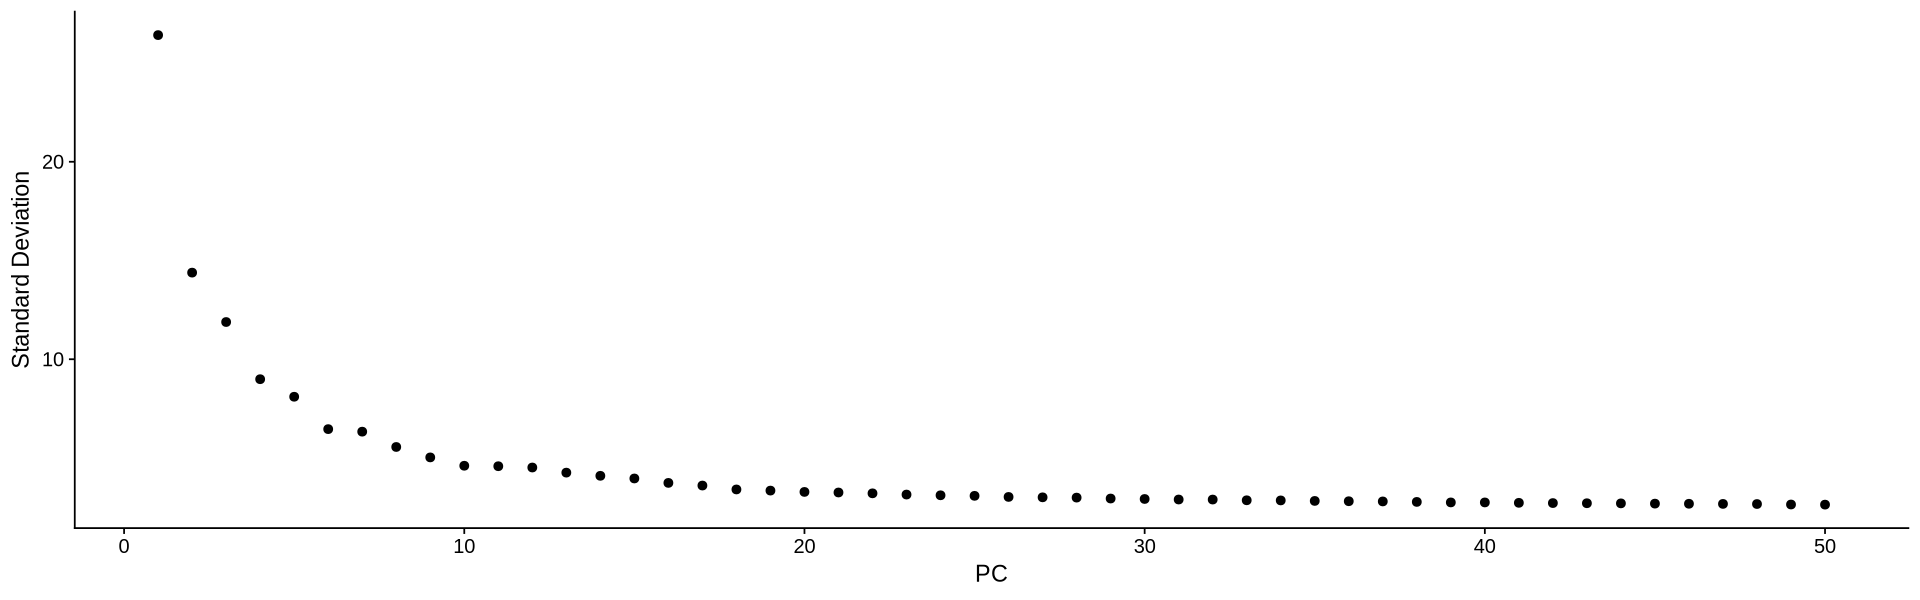

In [42]:
DefaultAssay(heart_cell_atlas) <- "SCT"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "pca_sct")

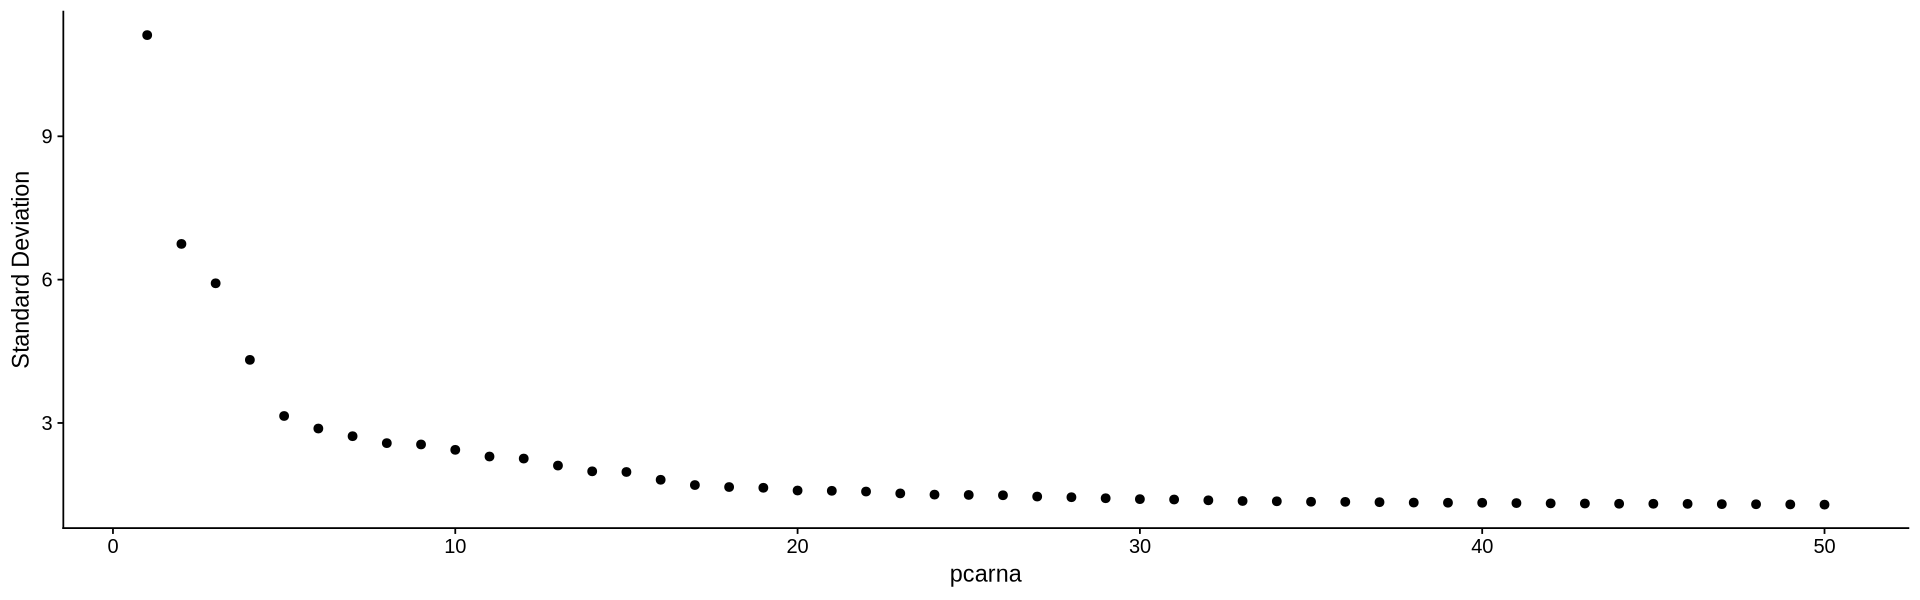

In [43]:
DefaultAssay(heart_cell_atlas) <- "RNA"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "pca_rna")

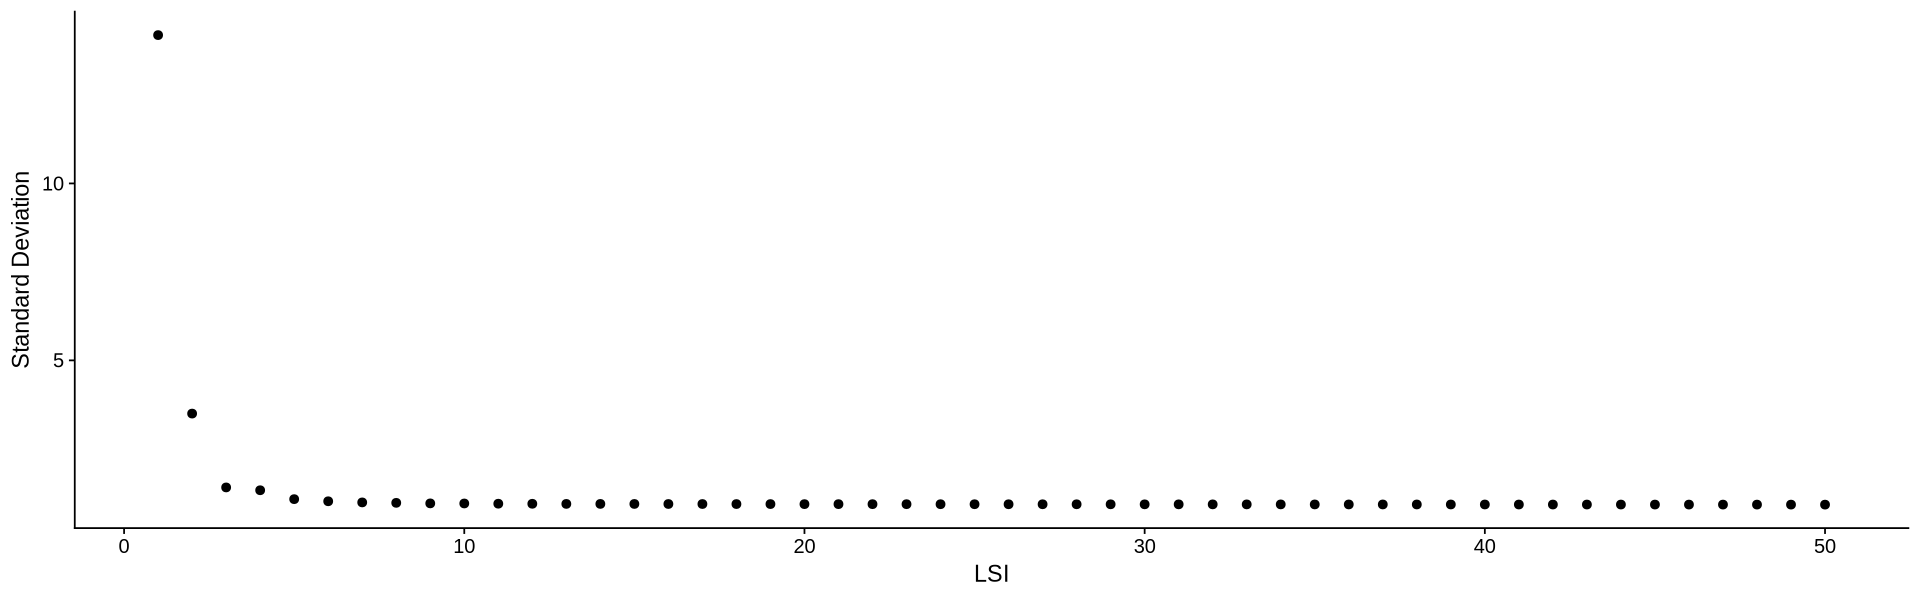

In [44]:
DefaultAssay(heart_cell_atlas) <- "peaks_macs2"
ElbowPlot(heart_cell_atlas, ndims = 50, reduction = "lsi")

In [45]:
heart_cell_atlas

An object of class Seurat 
611564 features across 8358 samples within 4 assays 
Active assay: peaks_macs2 (126746 features, 126741 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, Peaks, SCT
 3 dimensional reductions calculated: pca_sct, pca_rna, lsi

## Reduction on RNA and peaks assay

In [46]:
DefaultAssay(heart_cell_atlas) <- "RNA" 
# build a joint neighbor graph using both assays
heart_cell_atlas <- FindMultiModalNeighbors(
  object = heart_cell_atlas,
  reduction.list = list("pca_rna", "lsi"), # on RNA and on peaks
  dims.list = list(1:30, 2:15),
  k.nn = 10,
  knn.graph.name = "wknn_RNA_peaks",
  snn.graph.name = "wsnn_RNA_peaks",
  weighted.nn.name = "weighted.nn.RNA_peaks",
  modality.weight.name = c("RNA.weight","peaks.weight"),
  verbose = TRUE
)

Calculating cell-specific modality weights

Finding 10 nearest neighbors for each modality.



Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph



In [47]:
# build a joint UMAP visualization
heart_cell_atlas <- RunUMAP(
  object = heart_cell_atlas,
  nn.name = "weighted.nn.RNA_peaks",
  reduction.name = "umap_RNA_peaks",
  verbose = TRUE
)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
16:59:27 UMAP embedding parameters a = 0.9922 b = 1.112



16:59:29 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 10

16:59:32 Initializing from normalized Laplacian + noise (using RSpectra)

16:59:32 Commencing optimization for 500 epochs, with 134394 positive edges

16:59:32 Using rng type: pcg

16:59:43 Optimization finished



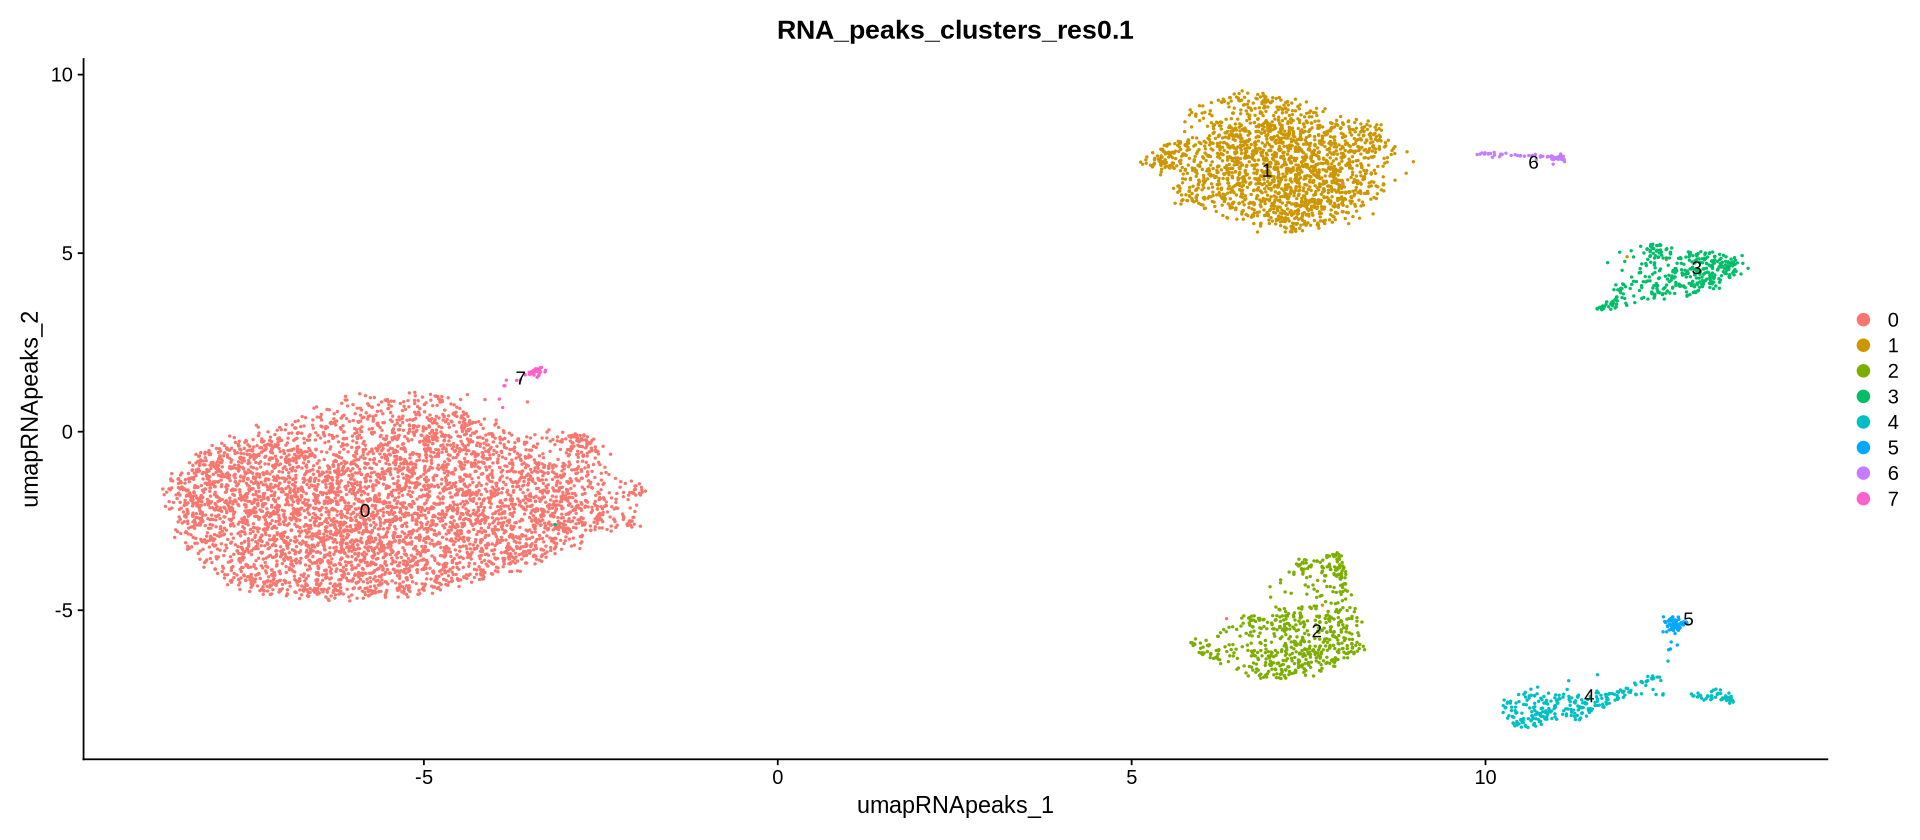

In [48]:
options(repr.plot.width=16, repr.plot.height=7)
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.1,verbose=FALSE, graph.name="wsnn_RNA_peaks", cluster.name = "RNA_peaks_clusters_res0.1")
DimPlot(heart_cell_atlas, reduction = "umap_RNA_peaks", group.by = "RNA_peaks_clusters_res0.1", label = TRUE, repel = TRUE)

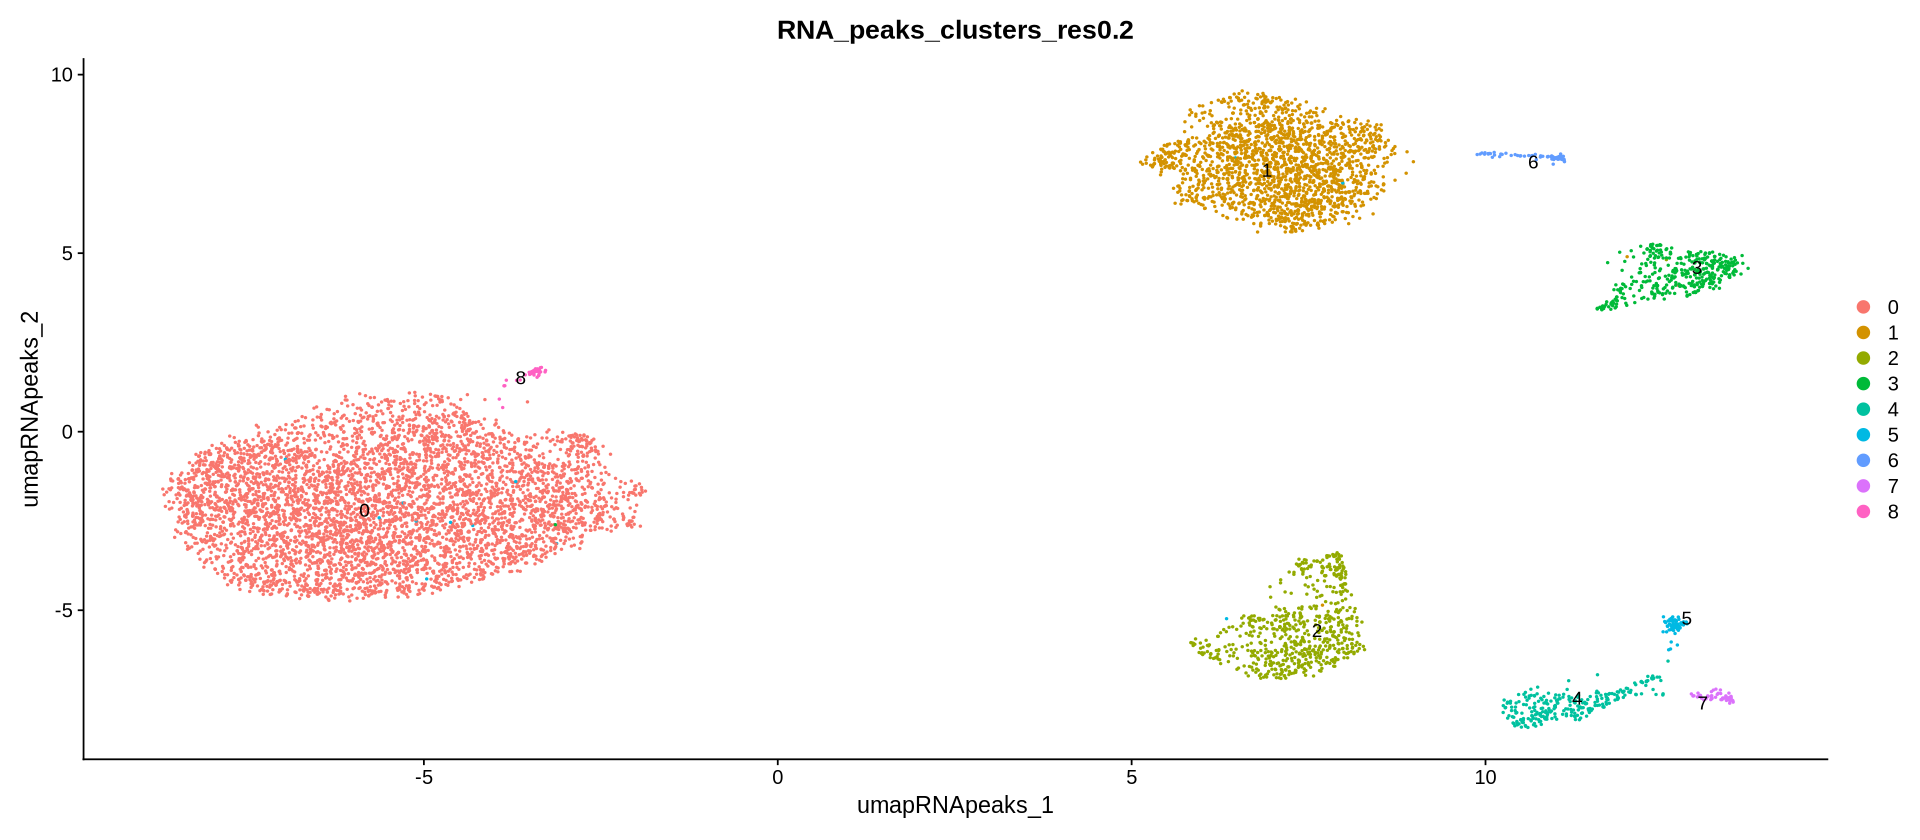

In [49]:
options(repr.plot.width=16, repr.plot.height=7)
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.2,verbose=FALSE, graph.name="wsnn_RNA_peaks", cluster.name = "RNA_peaks_clusters_res0.2")
DimPlot(heart_cell_atlas, reduction = "umap_RNA_peaks", group.by = "RNA_peaks_clusters_res0.2", label = TRUE, repel = TRUE)

## Reduction on SCT and peaks assay

Calculating cell-specific modality weights



Finding 10 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

17:18:00 UMAP embedding parameters a = 0.9922 b = 1.112

17:18:02 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 10

17:18:05 Initializing from normalized Laplacian + noise (using RSpectra)

17:18:05 Commencing optimization for 500 epochs, with 136052 positive edges

17:18:05 Using rng type: pcg

17:18:15 Optimization finished



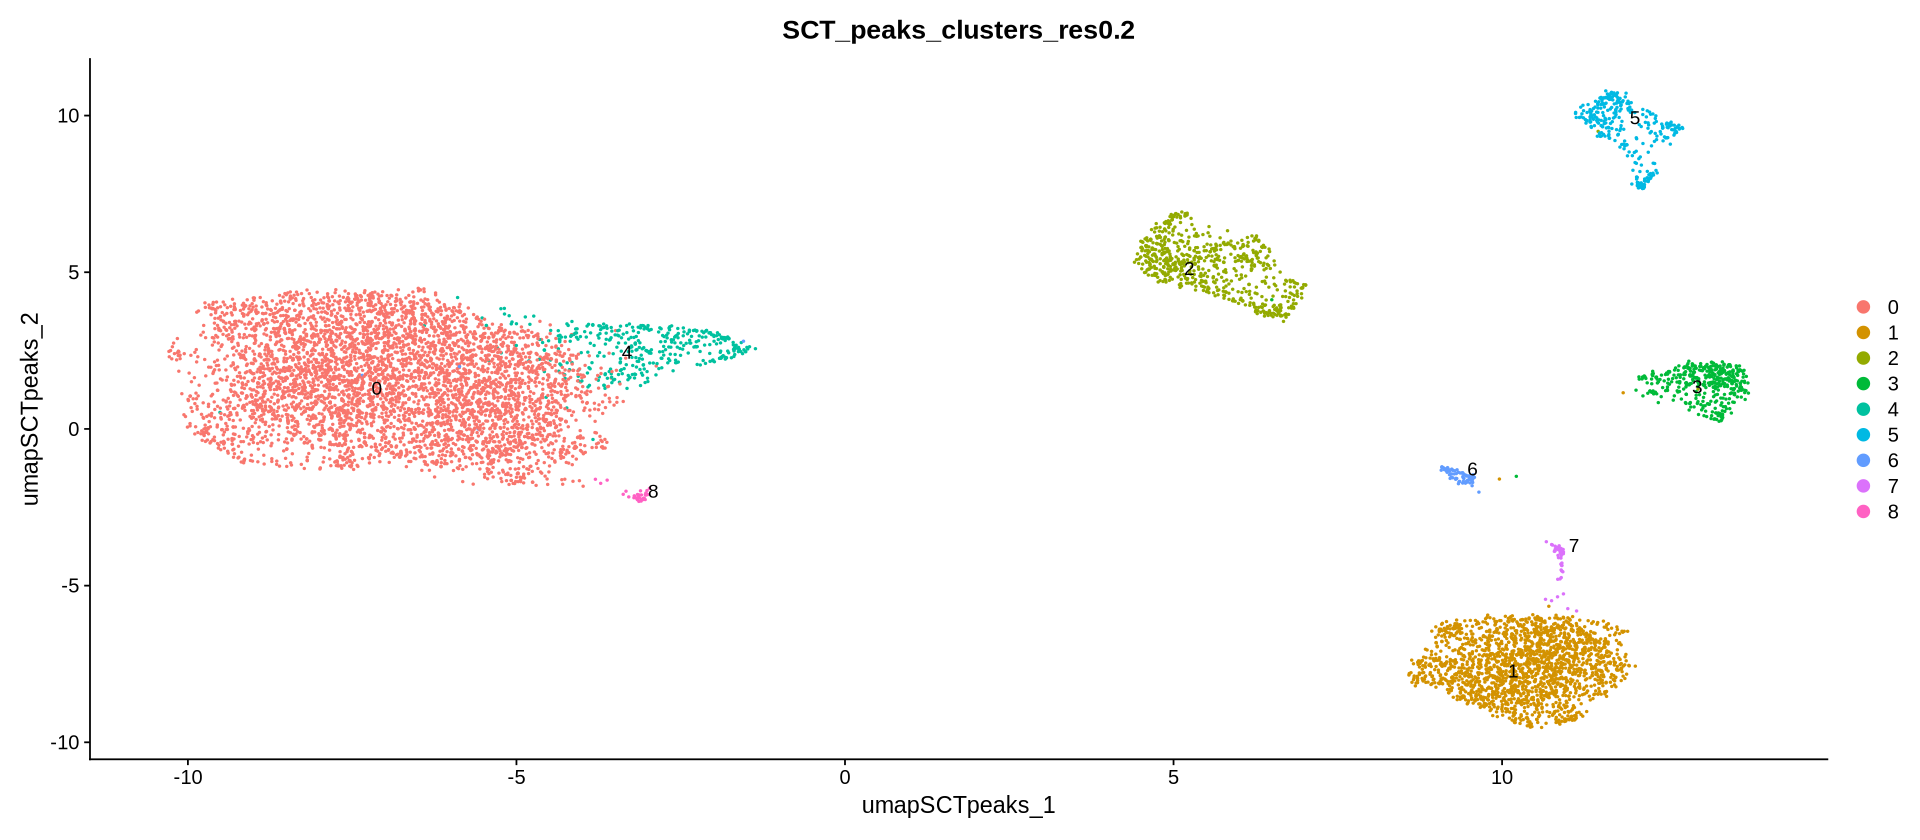

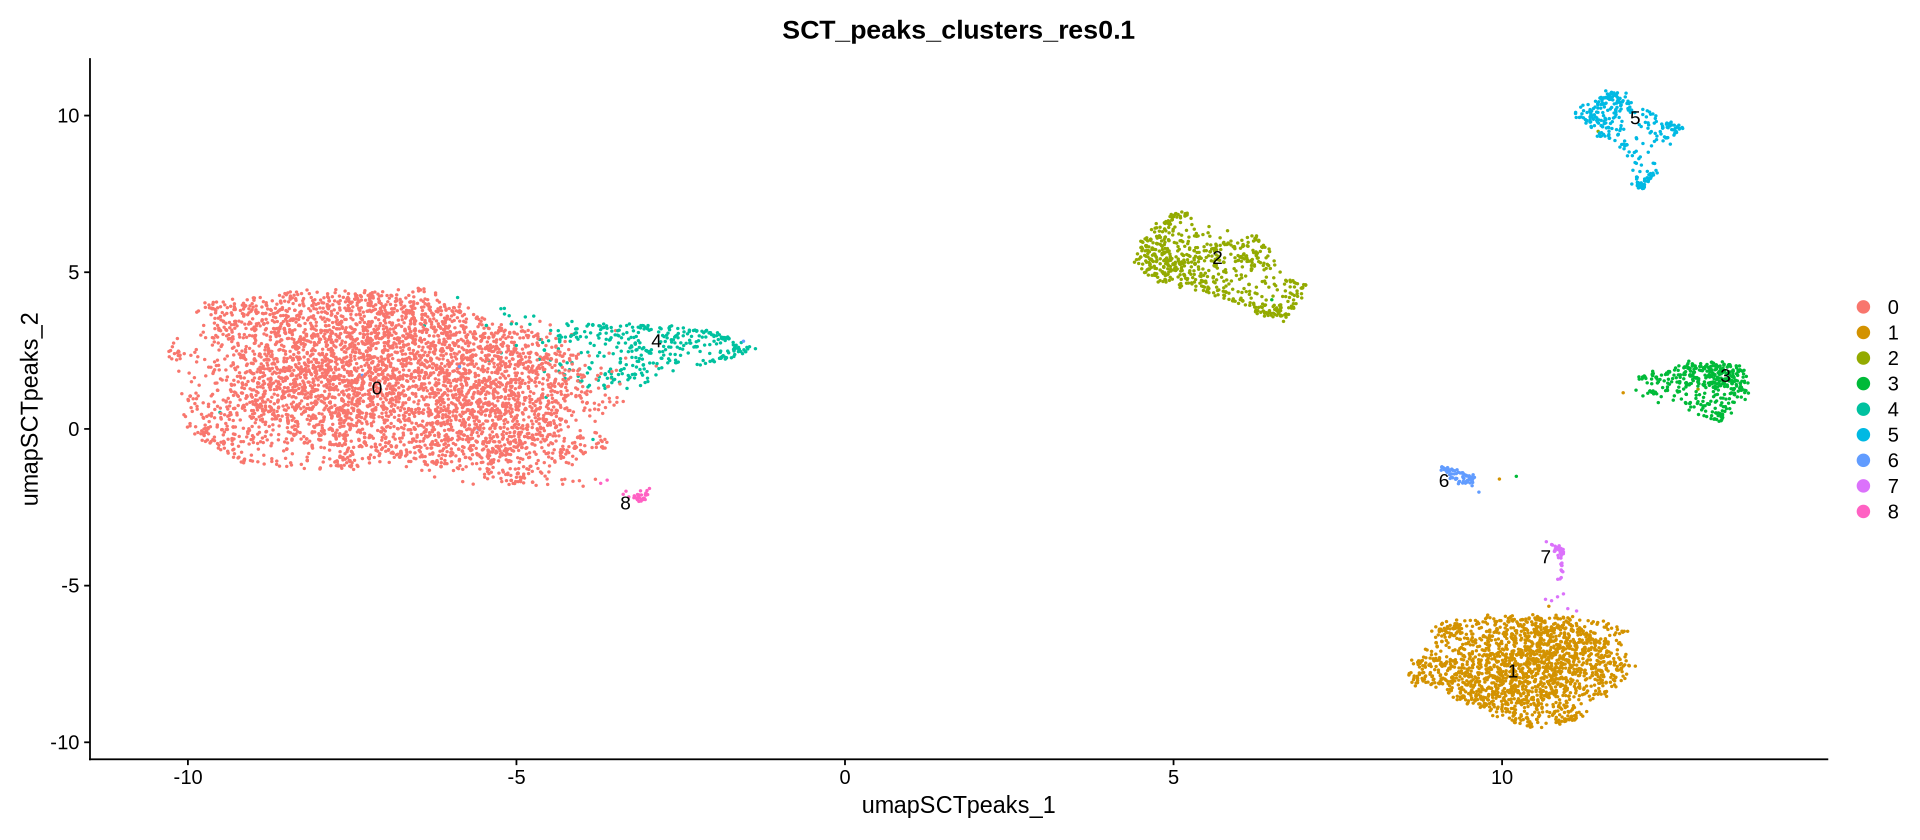

In [50]:
DefaultAssay(heart_cell_atlas) <- "SCT" 
# build a joint neighbor graph using both assays
heart_cell_atlas <- FindMultiModalNeighbors(
  object = heart_cell_atlas,
  reduction.list = list("pca_sct", "lsi"), # on SCT and on peaks
  dims.list = list(1:30, 2:15),
  k.nn = 10,
  knn.graph.name = "wknn_SCT_peaks",
  snn.graph.name = "wsnn_SCT_peaks",
  weighted.nn.name = "weighted.nn.SCT_peaks",
  modality.weight.name = c("SCT.weight","peaks.weight"),
  verbose = TRUE
)

# build a joint UMAP visualization
heart_cell_atlas <- RunUMAP(
  object = heart_cell_atlas,
  nn.name = "weighted.nn.SCT_peaks",
  reduction.name = "umap_SCT_peaks",
  verbose = TRUE
)

# Clustering
heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.2, verbose=FALSE, graph.name="wsnn_SCT_peaks", cluster.name = "SCT_peaks_clusters_res0.2")
DimPlot(heart_cell_atlas, reduction = "umap_SCT_peaks", group.by = "SCT_peaks_clusters_res0.2", label = TRUE, repel = TRUE)

heart_cell_atlas <- FindClusters(heart_cell_atlas, resolution = 0.1, verbose=FALSE, graph.name="wsnn_SCT_peaks", cluster.name = "SCT_peaks_clusters_res0.1")
DimPlot(heart_cell_atlas, reduction = "umap_SCT_peaks", group.by = "SCT_peaks_clusters_res0.1", label = TRUE, repel = TRUE)

In [51]:
saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"), compress = "xz")

In [57]:
sample_to_use <- "HCAHeartST11350194_HCAHeartST11445771"
out_dir <- "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data_renamed_genes"
heart_cell_atlas = readRDS(paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"))

In [58]:
str(heart_cell_atlas[["RNA"]], max.level = 3)

Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  ..@ layers    :List of 3
  .. ..$ counts    :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..$ data      :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..$ scale.data: num [1:2000, 1:8358] -0.0146 -0.033 -0.2671 -0.3101 -0.1644 ...
  ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  ..@ features  :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  ..@ default   : int 1
  ..@ assay.orig: chr(0) 
  ..@ meta.data :'data.frame':	32724 obs. of  8 variables:
  .. ..$ vf_vst_counts_mean                 : num [1:32724] 0 0 0 0.00347 0.000239 ...
  .. ..$ vf_vst_counts_variance             : num [1:32724] 0 0 0 0.003458 0.000239 ...
  .. ..$ vf_vst_counts_variance.expected    : num [1:32724] 0 0 0 0.003891 0.000243 ...
  .. ..$ vf_vst_counts_variance.standardized: num [1:32724] 0 0 0 0.889 0.983 ...
  .. ..$ vf_vst_counts_variable             : logi [1:32724] FALSE F

In [59]:
unique(heart_cell_atlas@meta.data["donor"])

,donor
,<chr>
AGGTATTGTCTTTGAC-1,A61


In [60]:
heart_cell_atlas

An object of class Seurat 
611564 features across 8358 samples within 4 assays 
Active assay: SCT (22266 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, Peaks, peaks_macs2
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [61]:
# heart_cell_atlas[["RNA"]]@layers$data
heart_cell_atlas[["RNA"]]$data

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]

  [[ suppressing 32 column names 'AGGTATTGTCTTTGAC-1', 'ACTTACTTCATTAGTG-1', 'CCTTCAATCAGCATTA-1' ... ]]



32724 x 8358 sparse Matrix of class "dgCMatrix"
                                                                                  
MIR1302-2HG  .         .         .         .         .         .         .        
FAM138A      .         .         .         .         .         .         .        
OR4F5        .         .         .         .         .         .         .        
AL627309.1   .         .         .         .         .         .         .        
AL627309.3   .         .         .         .         .         .         .        
AL627309.2   .         .         .         .         .         .         .        
AL627309.4   .         .         .         .         .         .         .        
AL732372.1   .         .         .         .         .         .         .        
OR4F29       .         .         .         .         .         .         .        
AC114498.1   .         .         .         .         .         .         .        
OR4F16       .         .         .     

In [62]:
heart_cell_atlas <- RenameAssays(
    object = heart_cell_atlas,
    Peaks = "ATAC",
    peaks_macs2 = "peaks"
)

Assays(heart_cell_atlas)

Warning message:
"Key 'peaks_' taken, using 'atac_' instead"
Warning message:
"Key 'peaksmacs2_' taken, using 'peaks_' instead"


[1] "RNA"   "SCT"   "ATAC"  "peaks"

In [63]:
DefaultAssay(heart_cell_atlas) <- "RNA"
heart_cell_atlas

An object of class Seurat 
611564 features across 8358 samples within 4 assays 
Active assay: RNA (32724 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: SCT, ATAC, peaks
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [64]:

saveRDS(heart_cell_atlas, file = paste0(out_dir,"/HCAHeartST11350194_HCAHeartST11445771_peaks_called_clustered.rds"), compress = "xz")

In [66]:
str(heart_cell_atlas, max.level = 3)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 4
  .. ..$ RNA  :Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. ..$ SCT  :Formal class 'SCTAssay' [package "Seurat"] with 9 slots
  .. ..$ ATAC :Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  .. ..$ peaks:Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ meta.data   :'data.frame':	8358 obs. of  85 variables:
  .. ..$ orig.ident                 : Factor w/ 1 level "SeuratProject": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA                 : num [1:8358] 19944 19892 19929 19826 19756 ...
  .. ..$ nFeature_RNA               : int [1:8358] 4928 5007 4824 4954 5088 4884 5285 5586 4879 4893 ...
  .. ..$ sangerID                   : chr [1:8358] "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" "HCAHeartST11350194" ...
  .. ..$ combinedID                 : chr [1:8358] "HCAHeartST11350194_HCAHeartST11445771" "HCAHeartST11350194_HCAHeartST

## FINDING BIOMARKERS for clusters: using cell_type
- by default: identifying positive and negative markers for each cluster, compared to each other cluster
- FindAllMarkers() automates this process for all clusters, but you can also test groups of clusters vs. each other, or against all cells.

FindMarkers(pbmc, ident.1 = 2, min.pct = 0.25)
- min.pct: minimum percentage of feature to be detected at a in either of the two groups of cells that are comp.
- logfc.threshold: requires a feature to be d.e. (on average) by some amount between the two groups. Increasing logfc.threshold speeds up the function, but can miss weaker signals.
- max.cells.per.ident: downsampling each group to parameter (increase speed at cost of accuracy)
- ident.1: label of forground cluster that is looked at
- ident.2: background cluster
    - can either be one number, or multiple: c(... , ...)
    - if parameter is not set, each cluster is compared against all others

In [70]:
# find markers for every cluster compared to all remaining cells
# report only the positive ones
Idents(heart_cell_atlas) <- "cell_type"
heart_cell_atlas.markers <- FindAllMarkers(heart_cell_atlas, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster Ventricular Cardiomyocyte



Calculating cluster Fibroblast

Calculating cluster Atrial Cardiomyocyte

Calculating cluster Endothelial cell

Calculating cluster Adipocyte

Calculating cluster Neural cell

Calculating cluster Myeloid

Calculating cluster Lymphoid

Calculating cluster Lymphatic Endothelial cell

Calculating cluster Mural cell

Calculating cluster Mast cell



In [71]:
# top 2 markers (highest avg logfc) for each cluster
library(dplyr)
top_2_markers <- heart_cell_atlas.markers %>%
    group_by(cluster) %>%
    slice_max(n = 2, order_by = avg_log2FC)

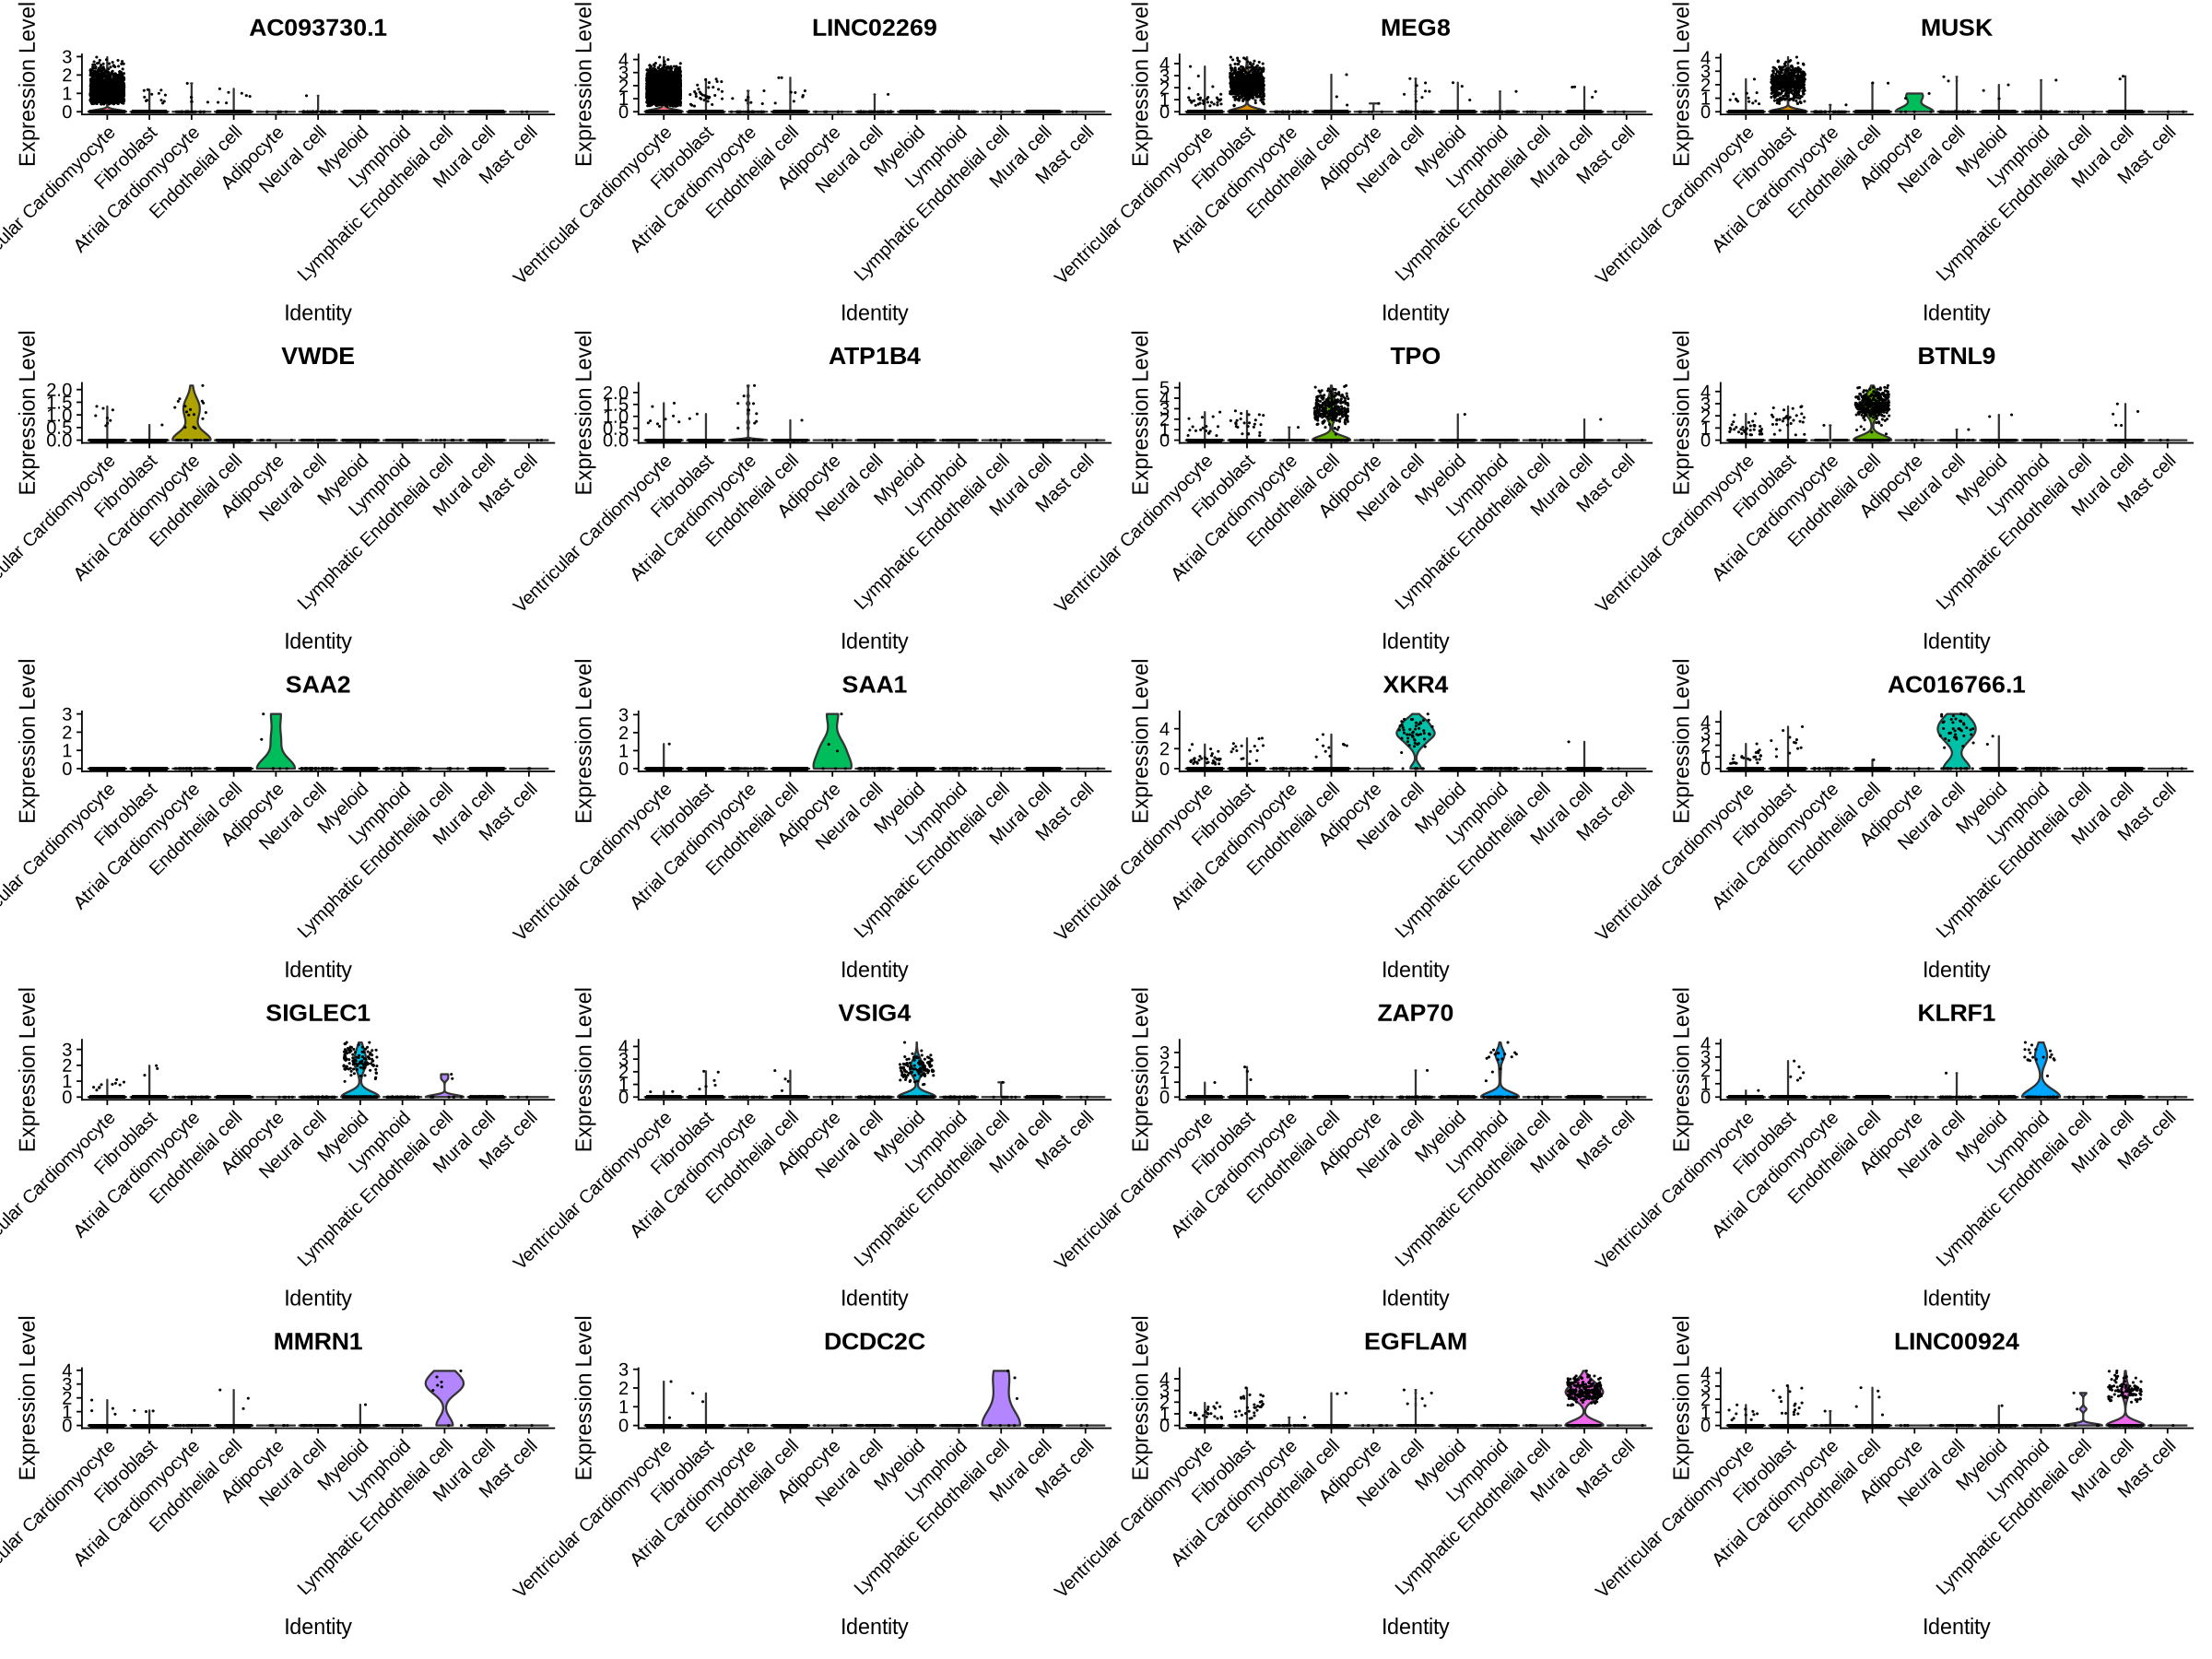

In [75]:
options(repr.plot.width=20, repr.plot.height=15)
DefaultAssay(heart_cell_atlas) <- "RNA" 
VlnPlot(heart_cell_atlas, features = top_2_markers$gene)

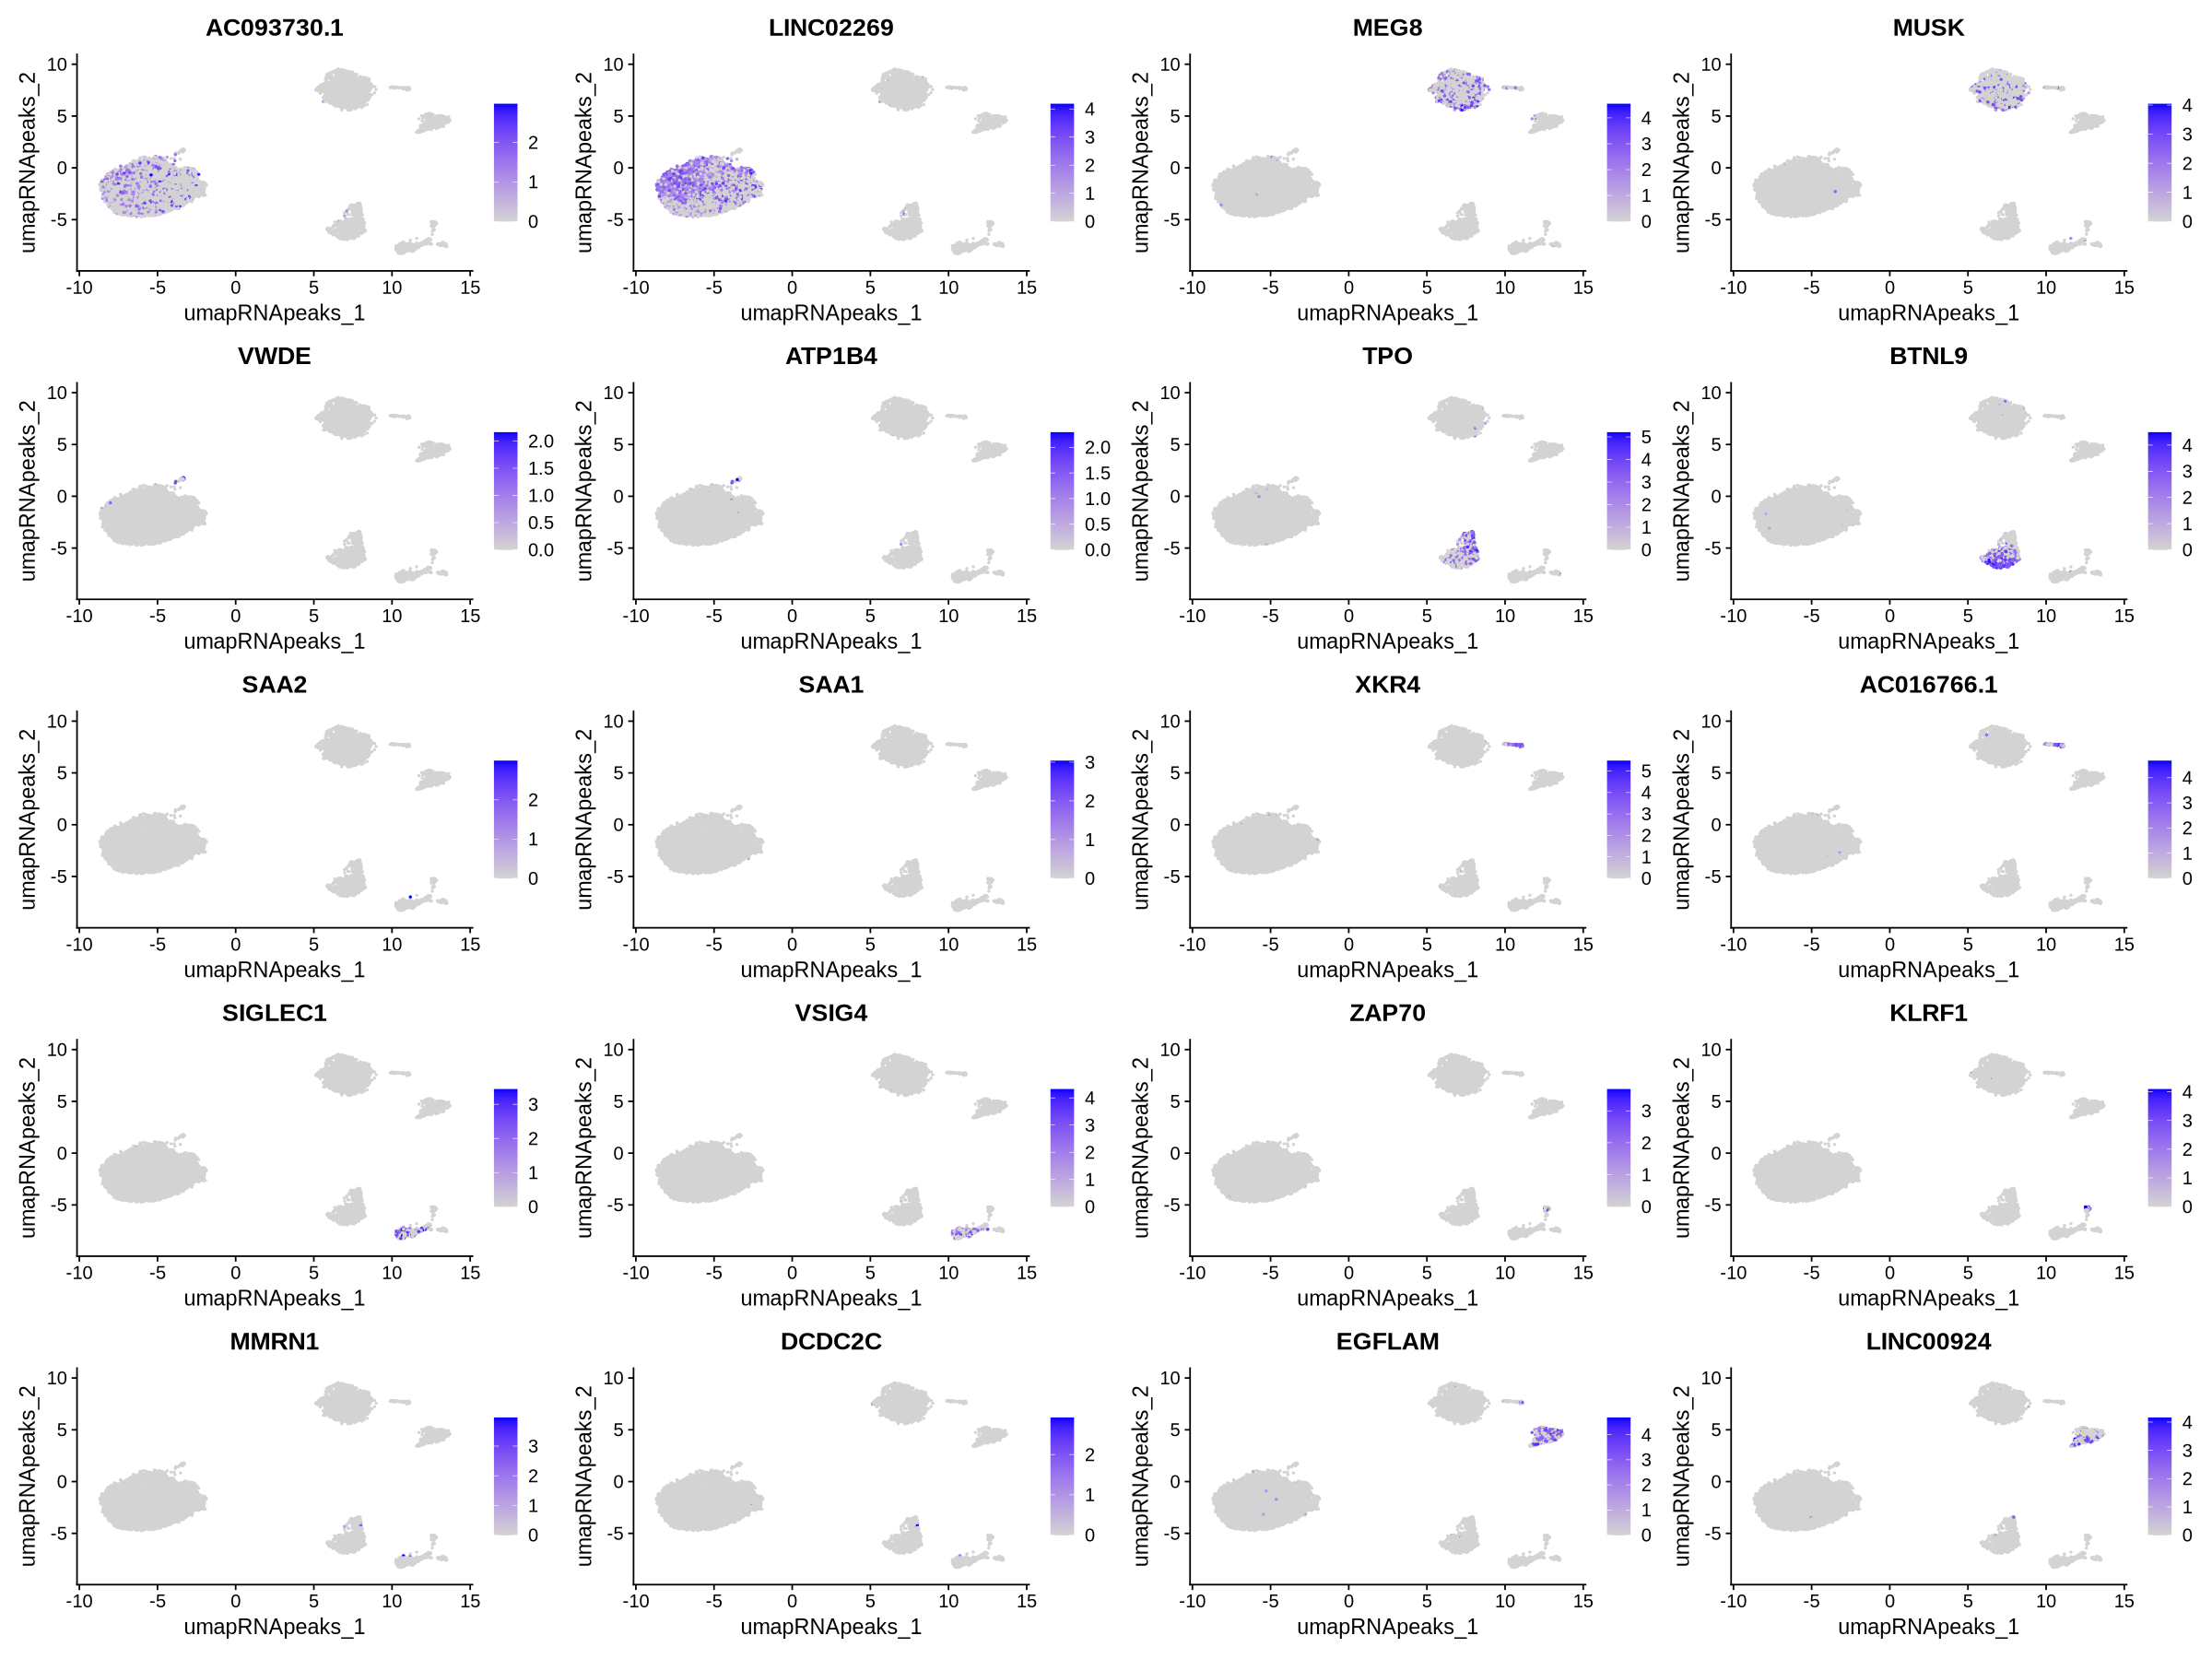

In [76]:
DefaultAssay(heart_cell_atlas) <- "RNA" 
FeaturePlot(heart_cell_atlas, features = top_2_markers$gene)

# pos and neg markers

In [77]:

all_markers <- FindAllMarkers(heart_cell_atlas, only.pos = FALSE, min.pct = 0.25, logfc.threshold = 0.25)

Calculating cluster Ventricular Cardiomyocyte



Calculating cluster Fibroblast

Calculating cluster Atrial Cardiomyocyte

Calculating cluster Endothelial cell

Calculating cluster Adipocyte

Calculating cluster Neural cell

Calculating cluster Myeloid

Calculating cluster Lymphoid

Calculating cluster Lymphatic Endothelial cell

Calculating cluster Mural cell

Calculating cluster Mast cell

Warning message:
"The following tests were not performed: "
Warning message:
"When testing Mast cell versus all:
	Cell group 1 has fewer than 3 cells"


In [78]:
heart_cell_atlas.markers.pos <- all_markers %>% 
  filter(avg_log2FC > 0) 
heart_cell_atlas.markers.neg <- all_markers %>%
  filter(avg_log2FC < 0)

summary(heart_cell_atlas.markers.pos$avg_log2FC)
summary(heart_cell_atlas.markers.neg$avg_log2FC)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2501  0.5387  1.2135  1.8905  2.6942 15.0264 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-11.9546  -3.9029  -1.5217  -2.3952  -0.6912  -0.2501 

In [79]:

heart_cell_atlas.markers.neg.top100 <- heart_cell_atlas.markers.neg %>%
  group_by(cluster) %>%
  arrange(desc(abs(avg_log2FC))) %>%
  slice_head(n = 100) %>%
  mutate(annotation = paste("marker.neg.", cluster, sep = ""))

heart_cell_atlas.markers.pos.top100 <- heart_cell_atlas.markers.pos %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC)) %>%
  slice_head(n = 100) %>%
  mutate(annotation = paste("marker.pos.", cluster, sep = ""))

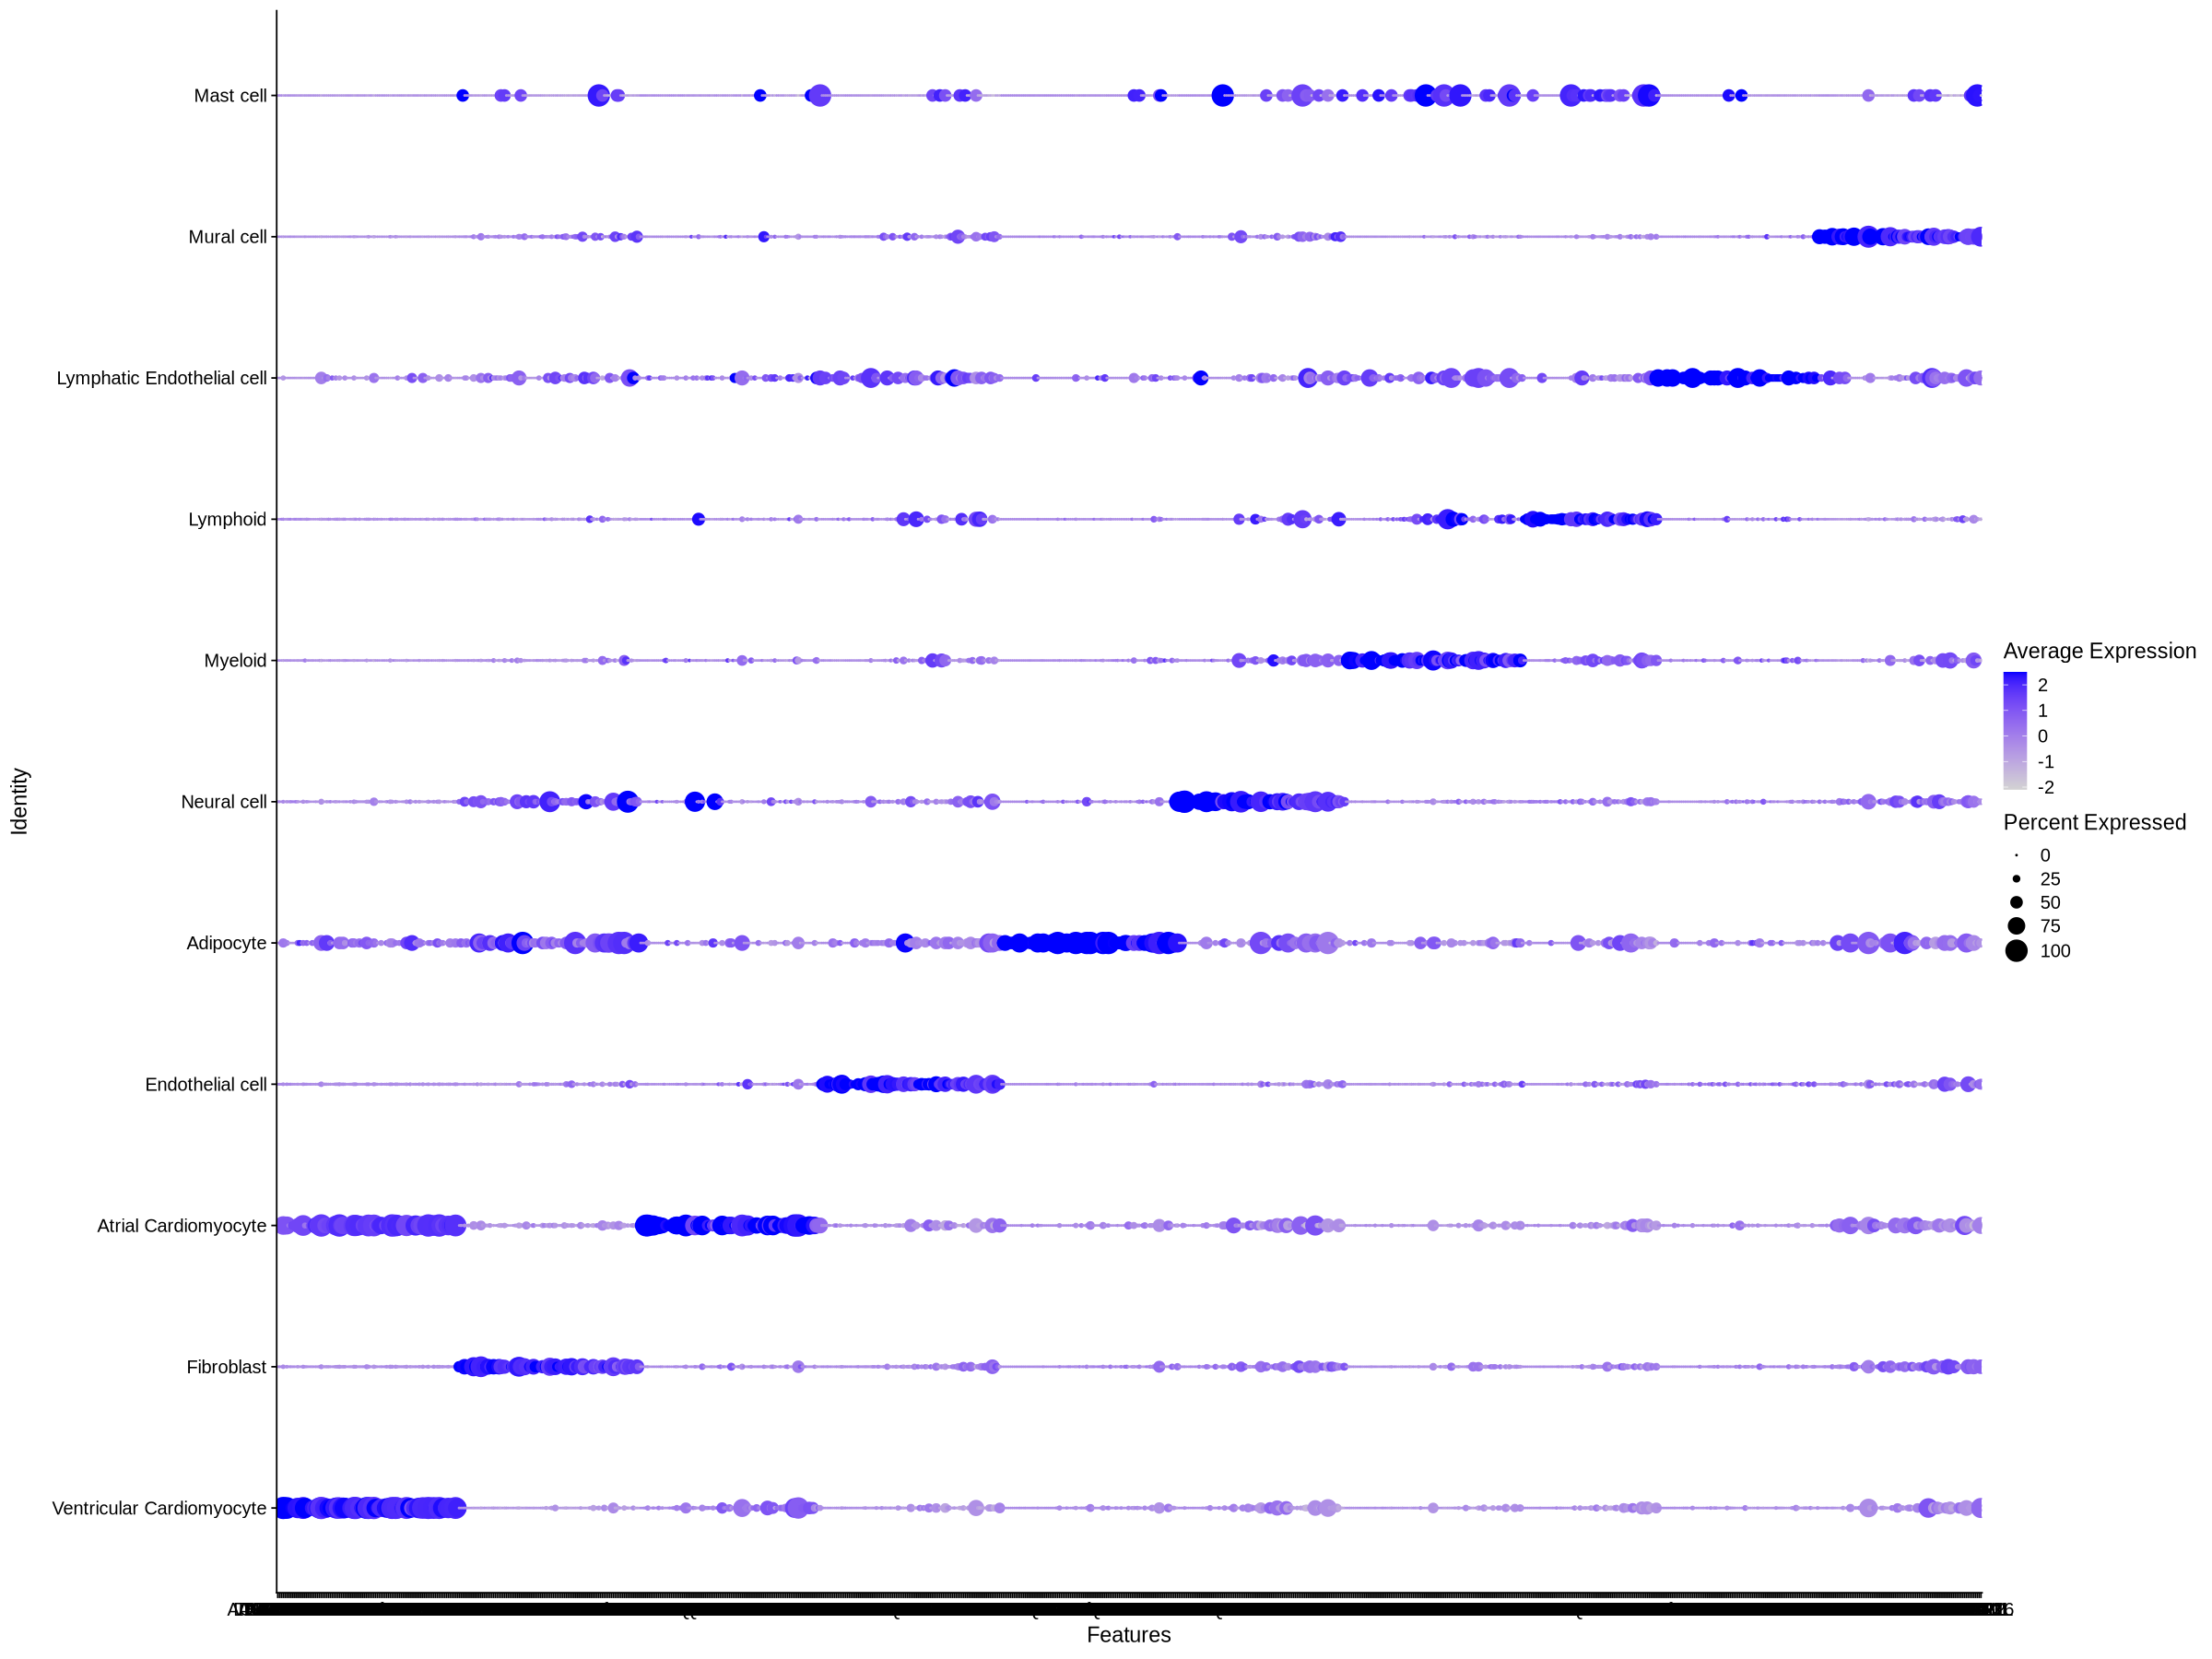

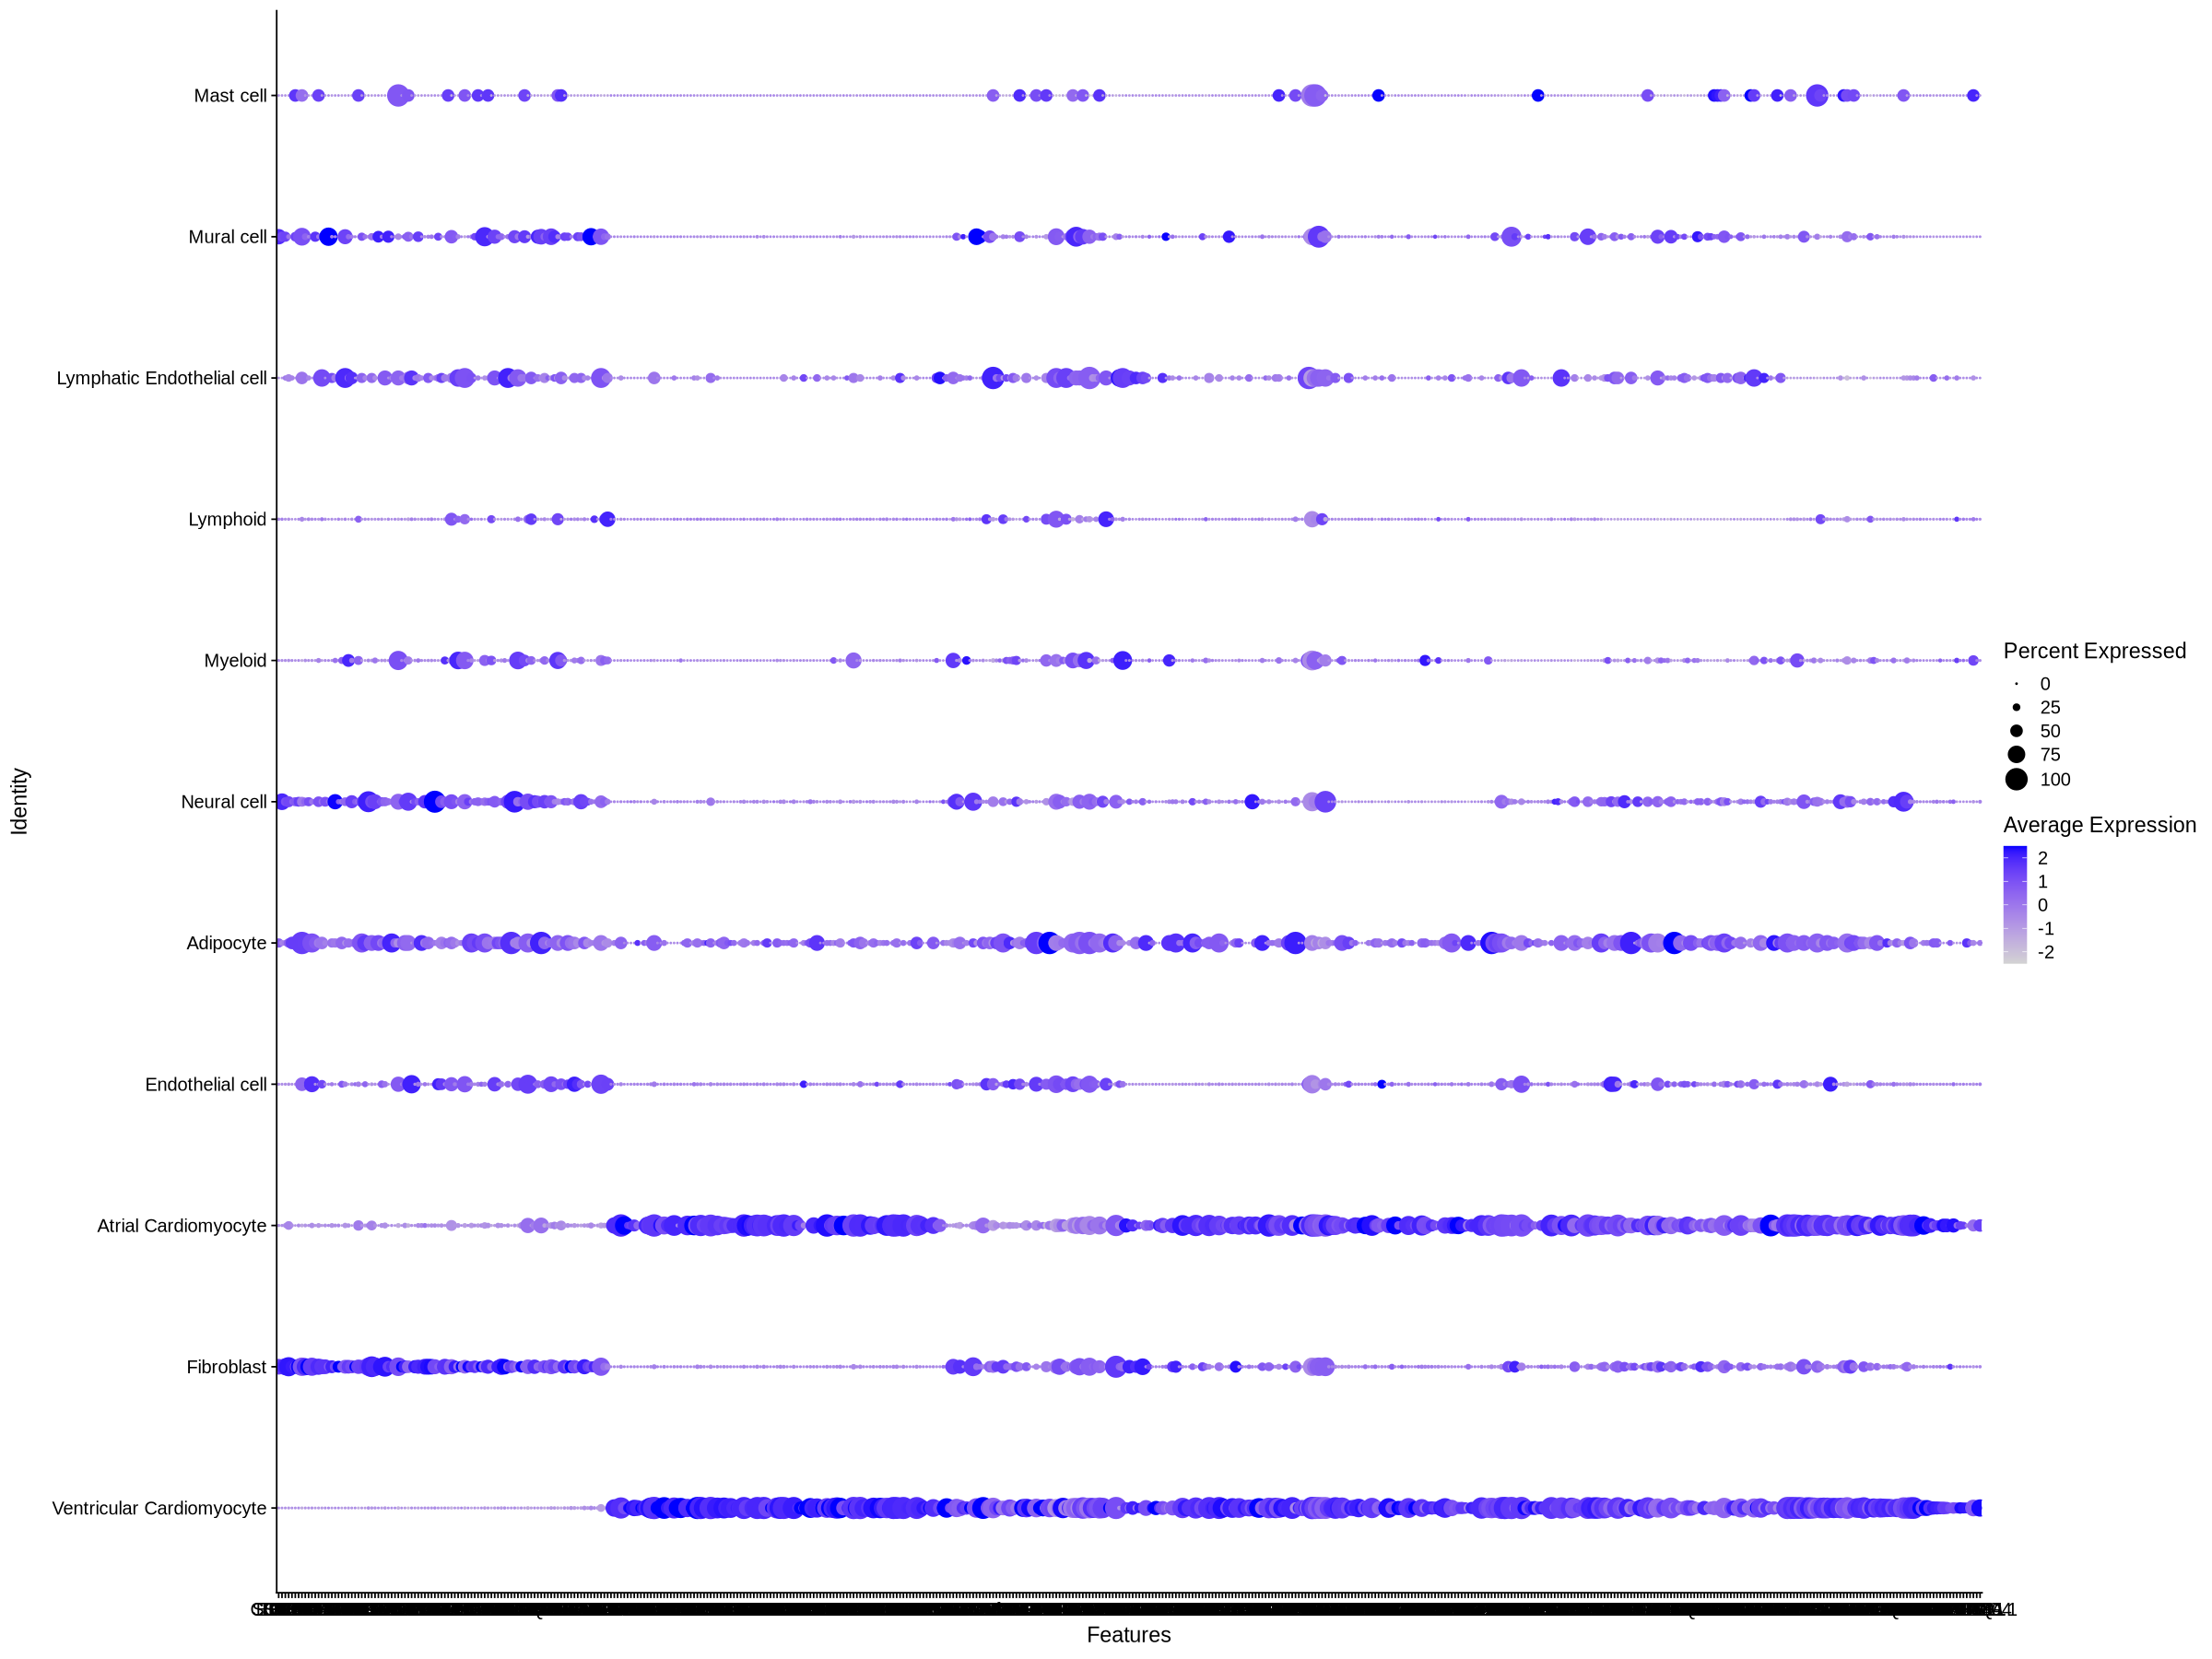

In [80]:
DotPlot(heart_cell_atlas, 
        features = unique(heart_cell_atlas.markers.pos.top100$gene))
DotPlot(heart_cell_atlas, 
        features = unique(heart_cell_atlas.markers.neg.top100$gene))

## find evenly high/low expressed genes

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   1.984    9.332   19.068   59.906   44.020 1958.475 

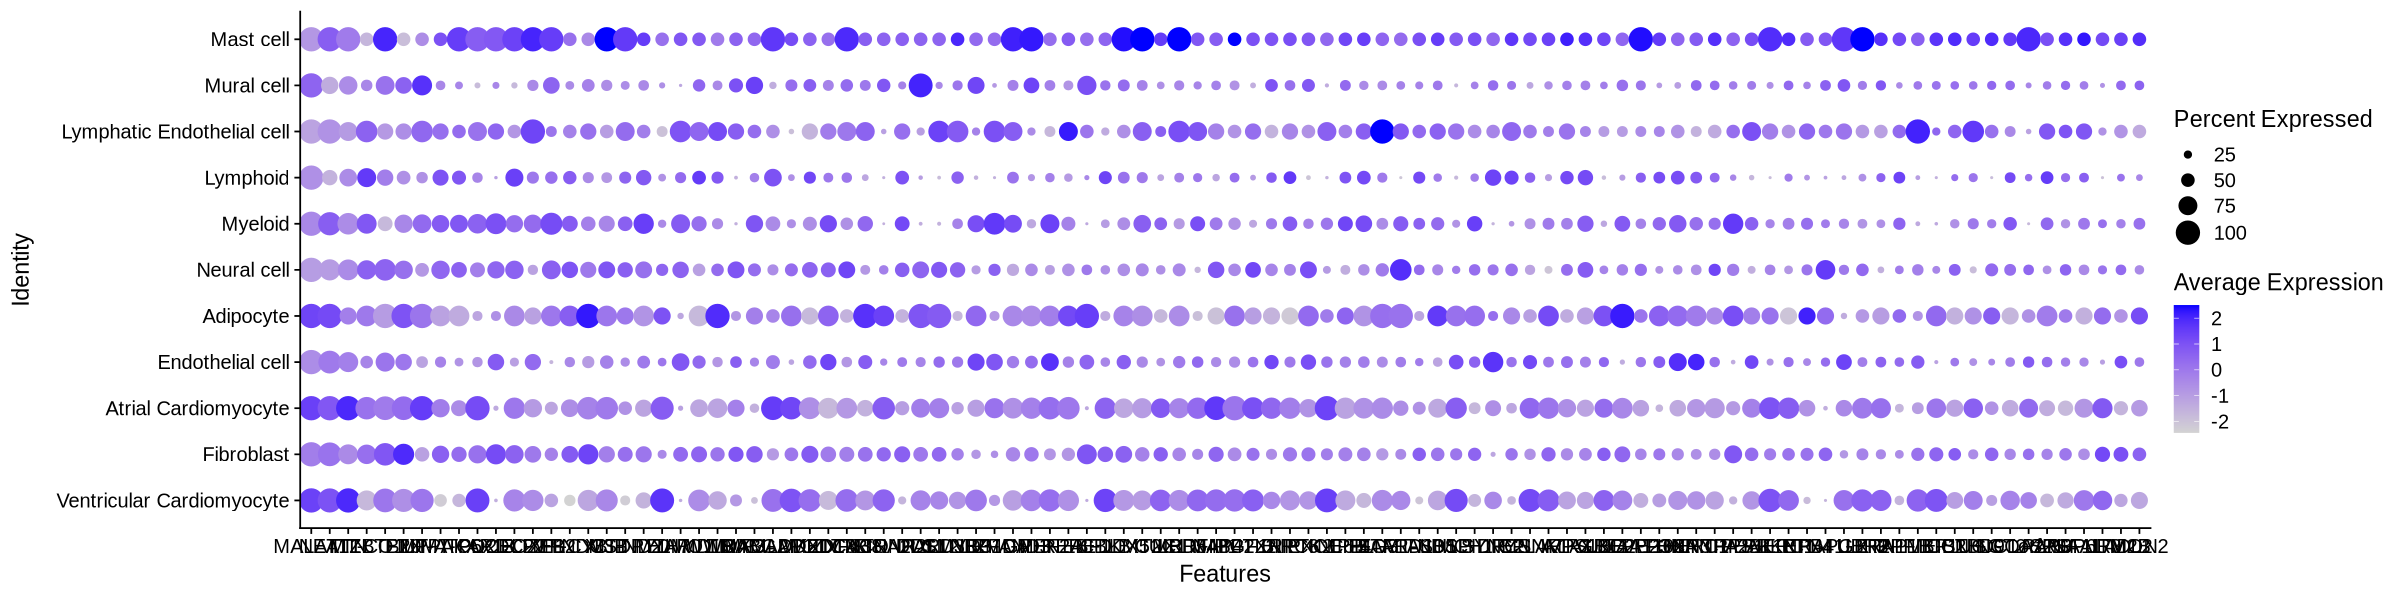

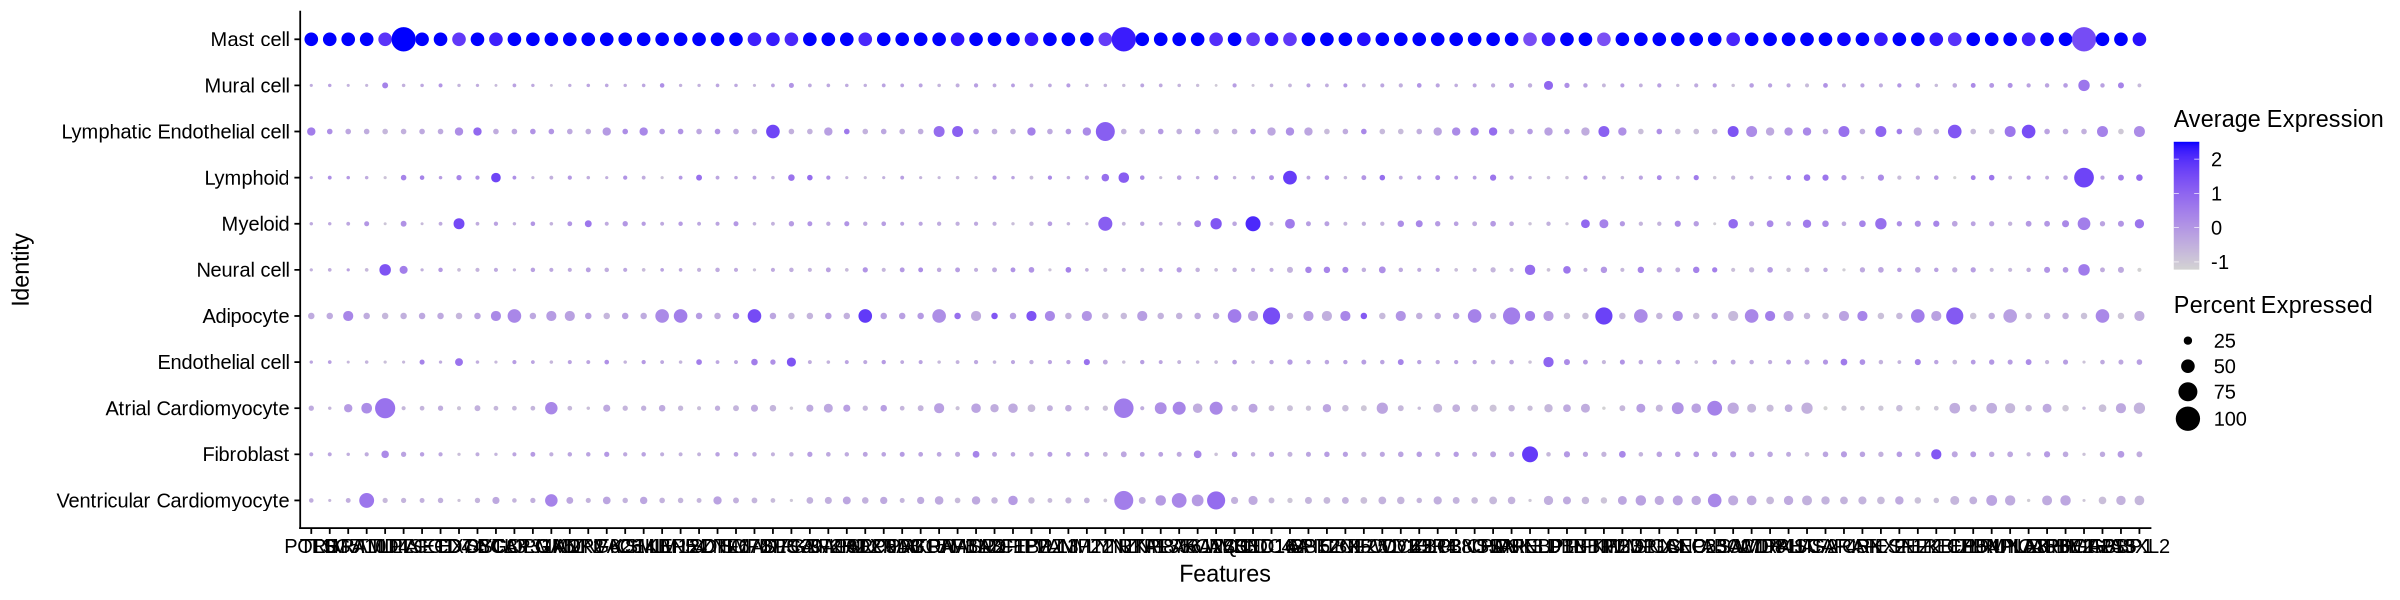

In [81]:
# Compute the average expression per gene per cluster.
avg_expr_list <- AverageExpression(heart_cell_atlas)
avg_expr_RNA <- avg_expr_list$RNA

# Remove genes that have zero expression in any cluster
has_zero <- apply(avg_expr_RNA, 1, function(gene) any(gene == 0))
expr_nonzero <- avg_expr_RNA[!has_zero, ]
expr_nonzero <- as.matrix(expr_nonzero)

# Compute a ratio of maximum to minimum expression across clusters for each gene (as a measure of expression variability)
expr_ratio <- rowMax(expr_nonzero) / rowMin(expr_nonzero)
summary(expr_ratio)
# expr_nonzero<- expr_nonzero[
#     (rowMax(expr_nonzero)/rowMin(expr_nonzero))] #-> filtered_expr can further be filtered based on this ratio if needed
# summary(expr_ratio)

# overall highly expressed genes:
# Rank genes by their median expression to identify overall highly or lowly expressed ones
gene_medians <- matrixStats::rowMedians(as.matrix(expr_nonzero))
# top 100 highly expressed genes
ranked_high <- order(gene_medians, decreasing = TRUE)
high_genes <- rownames(expr_nonzero)[ranked_high[1:100]]

# top 100 lowly expressed genes
ranked_low <- order(gene_medians)
low_genes <- rownames(expr_nonzero)[ranked_low[1:100]]

# Visualize the expression of these genes using DotPlot
options(repr.plot.width = 20, repr.plot.height = 5)
DotPlot(heart_cell_atlas, 
        features = high_genes)
DotPlot(heart_cell_atlas, 
        features = low_genes)




In [82]:
intersect(low_genes,high_genes)
# nice, no intersect

character(0)

In [83]:

n_clusters <- length(unique(Idents(heart_cell_atlas)))

high_expr_overall <- data.frame(
  p_val = NA,
  avg_log2FC = NA,
  pct.1 = NA,
  pct.2 = NA,
  p_val_adj = NA,
  cluster = rep(seq_len(n_clusters) - 1, each = length(high_genes)),
  gene = rep(high_genes, times = n_clusters),
  annotation = "overall_highly_expressed"
)

low_expr_overall <- data.frame(
  p_val = NA,
  avg_log2FC = NA,
  pct.1 = NA,
  pct.2 = NA,
  p_val_adj = NA,
  cluster = rep(seq_len(n_clusters) - 1, each = length(low_genes)),
  gene = rep(low_genes, times = n_clusters),
  annotation = "overall_lowly_expressed"
)

head(high_expr_overall)
head(low_expr_overall)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,annotation
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<chr>,<chr>
1,NA,NA,NA,NA,NA,0,MALAT1,overall_highly_expressed
2,NA,NA,NA,NA,NA,0,NEAT1,overall_highly_expressed
3,NA,NA,NA,NA,NA,0,TTN,overall_highly_expressed
4,NA,NA,NA,NA,NA,0,MT-CO1,overall_highly_expressed
5,NA,NA,NA,NA,NA,0,ZBTB20,overall_highly_expressed
6,NA,NA,NA,NA,NA,0,FTX,overall_highly_expressed


,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,annotation
,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<chr>,<chr>
1,NA,NA,NA,NA,NA,0,POLH,overall_lowly_expressed
2,NA,NA,NA,NA,NA,0,TRIM5,overall_lowly_expressed
3,NA,NA,NA,NA,NA,0,TSGA10,overall_lowly_expressed
4,NA,NA,NA,NA,NA,0,GRAMD4,overall_lowly_expressed
5,NA,NA,NA,NA,NA,0,TTLL7,overall_lowly_expressed
6,NA,NA,NA,NA,NA,0,LITAF,overall_lowly_expressed


## put together all markers

In [85]:

markers.annotated<-rbind(low_expr_overall, 
                         high_expr_overall, 
                         heart_cell_atlas.markers.neg.top100,
                         heart_cell_atlas.markers.pos.top100 )

In [86]:
heart_cell_atlas@misc$markers.annotated<-markers.annotated

In [87]:

saveRDS(heart_cell_atlas, "/nfs/data3/mopitas/mapra/cell_atlas_data/rds_data_renamed_genes/HCAHeartST11350194_HCAHeartST11445771_heart_cell_atlas_preprocessed.rds")

# not executed after this